# This notebook extracts 3-4-5 sequences from programs Alpha, Bravo, Charlie, Delta, and Echo.

# Import

In [1]:
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import random
import tensorflow as tf
import numpy as np
import timeit
from sklearn import metrics
import scipy.io as sio
import csv
import os
import math 
import random as rand
from numpy import genfromtxt
from numpy import sum,isrealobj,sqrt
from numpy.random import standard_normal

#import torch
#from torch import nn

import warnings
from scipy.spatial import distance



import sys
sys.path.append("..") # Adds higher directory to python modules path.

from Modules.Tools import MapTool
from Modules.Tools import BoxPlot
from Modules.Tools import peakCorrelation as pC

In [2]:
# Signal 
params = {'legend.fontsize': 50,
          'figure.figsize': (45, 15),
         'axes.labelsize': 60,
         'axes.titlesize':70,
         'xtick.labelsize':50,
         'ytick.labelsize':50,
         'lines.linewidth': 8}
plt.rcParams.update(params)

# Notebook Parameters
- this is simply for obtaining the graphs with manual mapping. Pad is closely relate to the sampling rate for the EM signal

In [3]:
save_folder = "./Graphs/1_2_SequenceExtractor/"
load_folder = "./Datasets/Numpy/FP_GANs_LargeScale_2/full/"
pad = 8
y_low=-2.8
y_high=2.8
amount=3200

In [4]:
def getValue(dataset, loc):
    list_peaks = []
    
    for peaks in dataset:
        list_peaks.append(peaks[loc])
    return np.array(list_peaks)

# Load Datasets

In [5]:
TS_1 = np.load(load_folder + "TS_1/TS_1_full.npy", allow_pickle=True)
TS_2 = np.load(load_folder + "TS_2/TS_2_full.npy", allow_pickle=True)
TS_3 = np.load(load_folder + "TS_3/TS_3_full.npy", allow_pickle=True)
TS_4 = np.load(load_folder + "TS_4/TS_4_full.npy", allow_pickle=True)
TS_5 = np.load(load_folder + "TS_5/TS_5_full.npy", allow_pickle=True)

In [6]:
TS_1.shape

(3000, 5631)

In [7]:
TS_2.shape

(3000, 5631)

In [8]:
TS_3.shape

(3000, 5569)

In [9]:
TS_4.shape

(3000, 5444)

In [10]:
TS_5.shape

(3000, 5037)

# Manual Mapping Signals

In [11]:
test_loc = 100

In [12]:
start_code = ["nop", "nop", "nop", "nop", "nop", 
              "nop", "nop", "nop", "nop", "nop",
             "nop", "nop"]
end_code = ["nop", "nop", "nop", "nop", "nop", 
            "nop", "nop", "nop", "nop", "nop",
            "nop", "nop",
            "clr", "clr", "clr", "clr", "clr",
            "clr", "clr", "clr", "clr", "clr",
            "clr",
            "out", "out", "out",
            "sts", "sts", "sts", "sts",
            "clc", "cln", "clz", "cli", "cls",
            "clv", "clt", "clh", 
            "rjmp", "sbi"]

In [13]:
TS_Program_1 = ["ori", "sts", "lds", "ori", "mov",
              
              "andi",
              "ori", "sts", "out", "lds", "ori",
              "sts", "lds", "ori", "mov", "andi",
              "push", "ori", "mov", "andi", "or",
              "push", "ori", "muls", "nop", "fmul",
              
              "pop",
              
              "sts", "lds", "ori", "muls", "nop",
              "sev", "sbis-f", "cp", "out", "lds",
              "mov", "com", "neg", "sbci", "tst",
              "push", "ori", "mov", "andi", "ldi",
             
              "pop",
                         
              "out", "lds", "ori", "sts",
              "cp", "brpl-f", "cli", "ori", "sts",
                         
              "lds", "ori", "sts", "bset", "push",
              "dec", "brne-t", "ldi", "add", "sub",
              "brpl-f", "cli", "ori", "sts", "lds",
                         
              "andi", "mov", "ori", "mov",
              "andi", "ori", "muls", "nop", "pop",
              
              "pop",
                         
              "ori", "sts", "ldi", "sub",
              "cln", "lds", "ori", "sts"           
              ]

TS_Program_2 = ["lds", "ori", "sts", "out", "lds",
              
              "lds", "ori", "mov", "andi", "mov",
              "sts", "out", "lds", "ori", "sts",
              "lds", "ori", "mov", "andi", "sev",
              "ori", "mov", "andi", "or", "mov",
              "ori", "muls", "nop", "fmul", "push",
                         
              "lds", "ori", "muls", "nop", "andi",
              "sbis-f", "cp", "out", "lds", "ori",
              "com", "neg", "sbci", "tst", "andi",
              "ori", "mov", "andi", "ldi", "swap",
                         
              "swap", "add", "eor", "sub",
              "ldi", "out", "lds", "ori", "sts",
                         
              "ori", "sts", "bset", "push", "andi",
              "brne-t", "ldi", "add", "sub", "pop",
              "cli", "ori", "sts", "lds", "ori", 
              
              "pop", "lds", "ori", "sts",
              "nop", "and", "ori", "muls", "nop",
                         
              "lds", "ori", "sts", "com",
              "sen", "ori", "sts", "lds", "ori"           
              ]

TS_Program_3 = ["ori", "sts", "lds", "ori", "mov", 
              
              "push",
                         
              "ori", "mov", "andi", "mov", "ori",
              "out", "lds", "ori", "sts", "lds",
              "ori", "mov", "andi", "sev", "sbis-f",
              "mov", "andi", "or", "mov", "com",
              "muls", "nop", "fmul", "push", "ori",
              
              "ori", "muls", "nop", "andi", "mov",
              "cp", "out", "lds", "ori", "sts",
              "neg", "sbci", "tst", "andi", "mov",
              "mov", "andi", "ldi", "swap", "add",
                         
              "andi", "mov", "ori", "mov",
              "andi", "dec", "brne-t", "ldi", "add",
                         
              "sts", "bset", "push", "andi", "mov",
              "ldi", "add", "sub", "pop", "lds",
              "ori", "sts", "lds", "ori", "pop",
                         
              "ori", "pop", "inc", "mov",
              "sbc", "jmp", "sub", "add", "nop",
                         
              "muls", "eor", "in", "tst",
              "brne-f", "fmul", "lds", "ori", "sts"           
              ]

TS_Program_4 = ["in", "push", "ori", "mov", "andi", 
                         
              "mov", "andi", "mov", "ori", "mov",
              "lds", "ori", "sts", "lds", "ori",
              "mov", "andi", "sev", "sbis-f", "cp", 
              "andi", "or", "mov", "com", "neg",
              "nop", "fmul", "push", "ori", "mov",
               
              "muls", "nop", "andi", "mov", "ori",
              "out", "lds", "ori", "sts", "ldi",
              "sbci", "tst", "andi", "mov", "ori",
              "andi", "ldi", "swap", "add", "eor",
                         
              "lds", "ori", "sts", "bset",
              "push", "andi", "mov", "ori", "mov",
                         
              "bset", "push", "andi", "mov", "ori",
              "add", "sub", "pop", "lds", "ori",
              "sts", "lds", "ori", "pop", "inc",
                         
              "jmp", "sub", "add", "nop",
              "pop", "andi", "mov", "ori", "mov",
              
              "pop",           
              
              "andi", "mov", "ori", "mov",
              "andi", "muls", "eor", "in", "tst",           
              ]

TS_Program_5 = ["ldi", "push", "ori", "muls", "nop", 
                         
              "andi", "mov", "ori", "mov", "andi",
              "ori", "sts", "lds", "ori", "muls",
              "andi", "sev", "sbis-f", "cp", "out",
              "or", "mov", "com", "neg", "sbci",
              "fmul", "push", "ori", "mov", "andi",
              
              "nop", "andi", "mov", "ori", "mov",
              "lds", "ori", "sts", "ldi", "sub",
              "tst", "andi", "mov", "ori", "mov",
              "ldi", "swap", "add", "eor", "sub",
               
              "andi", "mov", "ori", "mov",           
              "andi", "andi", "ori", "mov", "andi",
              
              "push", "andi", "mov", "ori", "mov",           
              "sub", "pop", "lds", "ori", "sts",           
              "lds", "ori", "pop", "inc", "mov",
              
              "pop",
                         
              "and", "ori", "muls", "nop",
              "out", "lds", "ori", "sts", "com"           
              ]

## TS_1

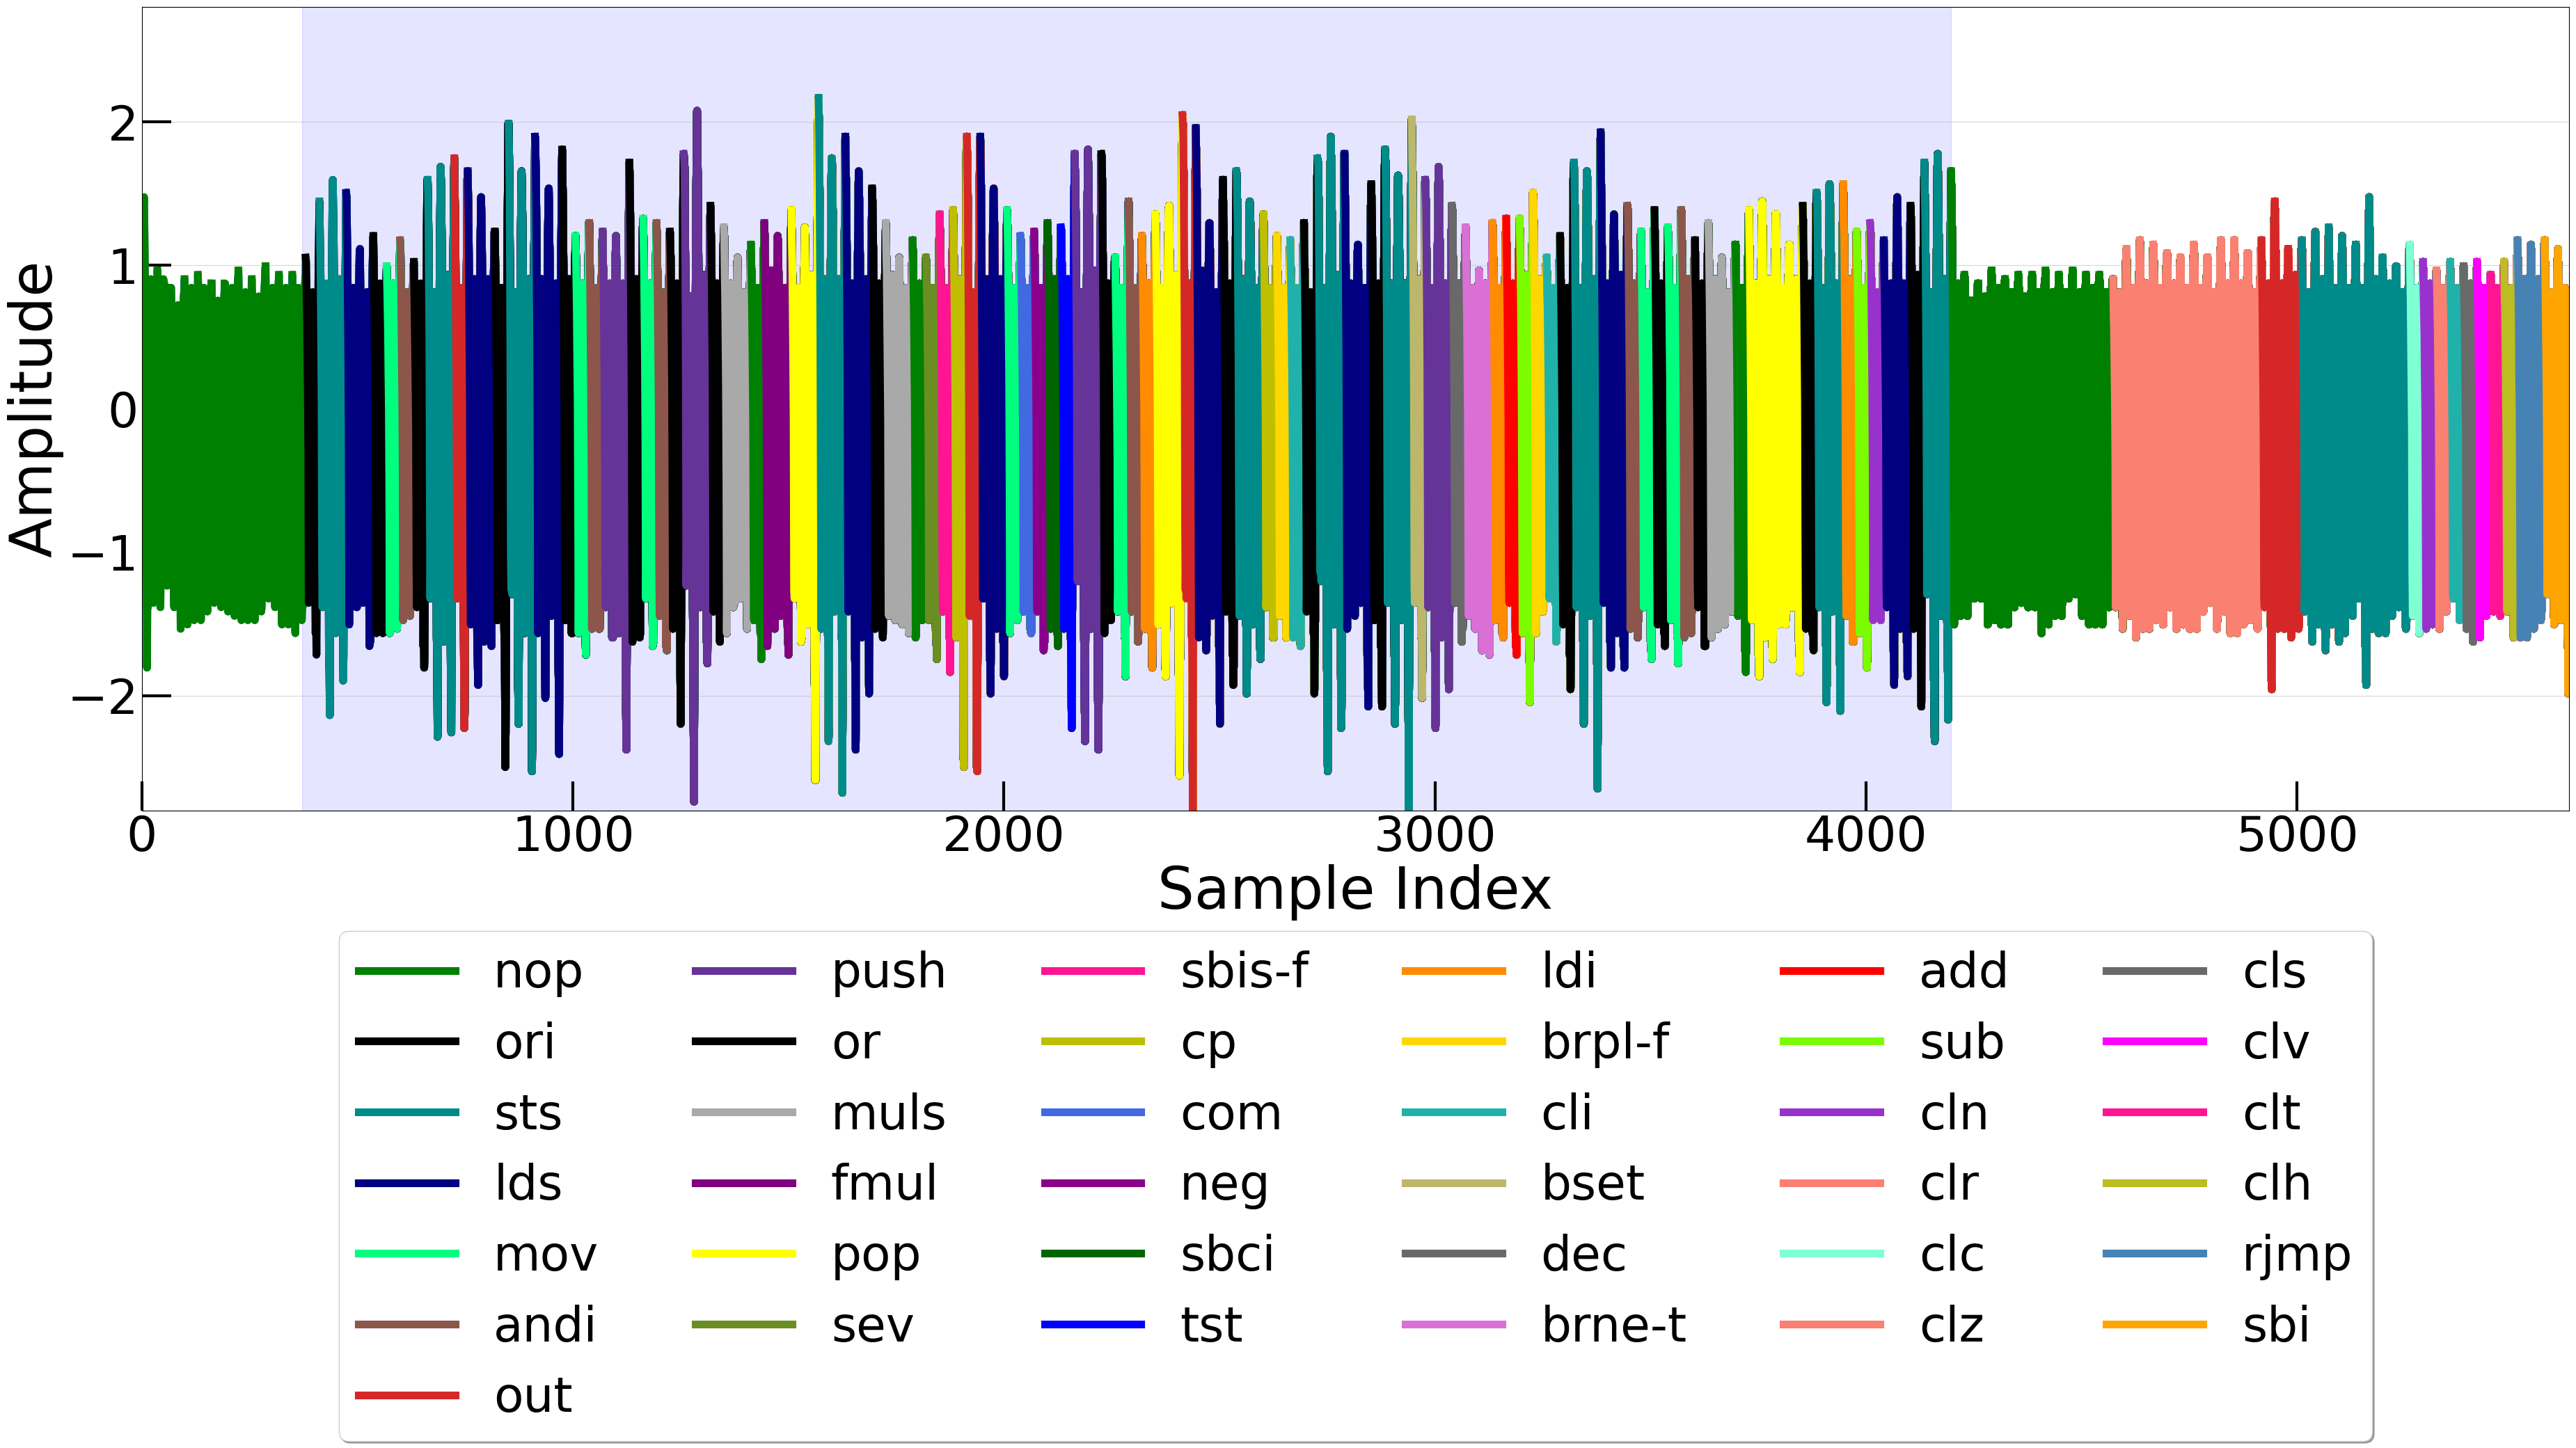

In [14]:
mid_code = TS_Program_1

code = start_code + mid_code + end_code

Signal = TS_1[test_loc]

time_Signal = np.arange(Signal.shape[0])
plt.plot(time_Signal, Signal)
MapTool.mapCodeSignal(Signal, code, pad)
plt.axvspan(MapTool.getPeaksLoc(Signal, pad, 24, False), MapTool.getPeaksLoc(Signal, pad, 268), color='blue', alpha=0.1)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True, ncol=6)
plt.xlim([0,len(Signal)])
plt.ylim(y_low,y_high)
#plt.savefig(save_folder + "Alpha_segment.png", bbox_inches='tight')
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.show()
plt.close()

## TS_2

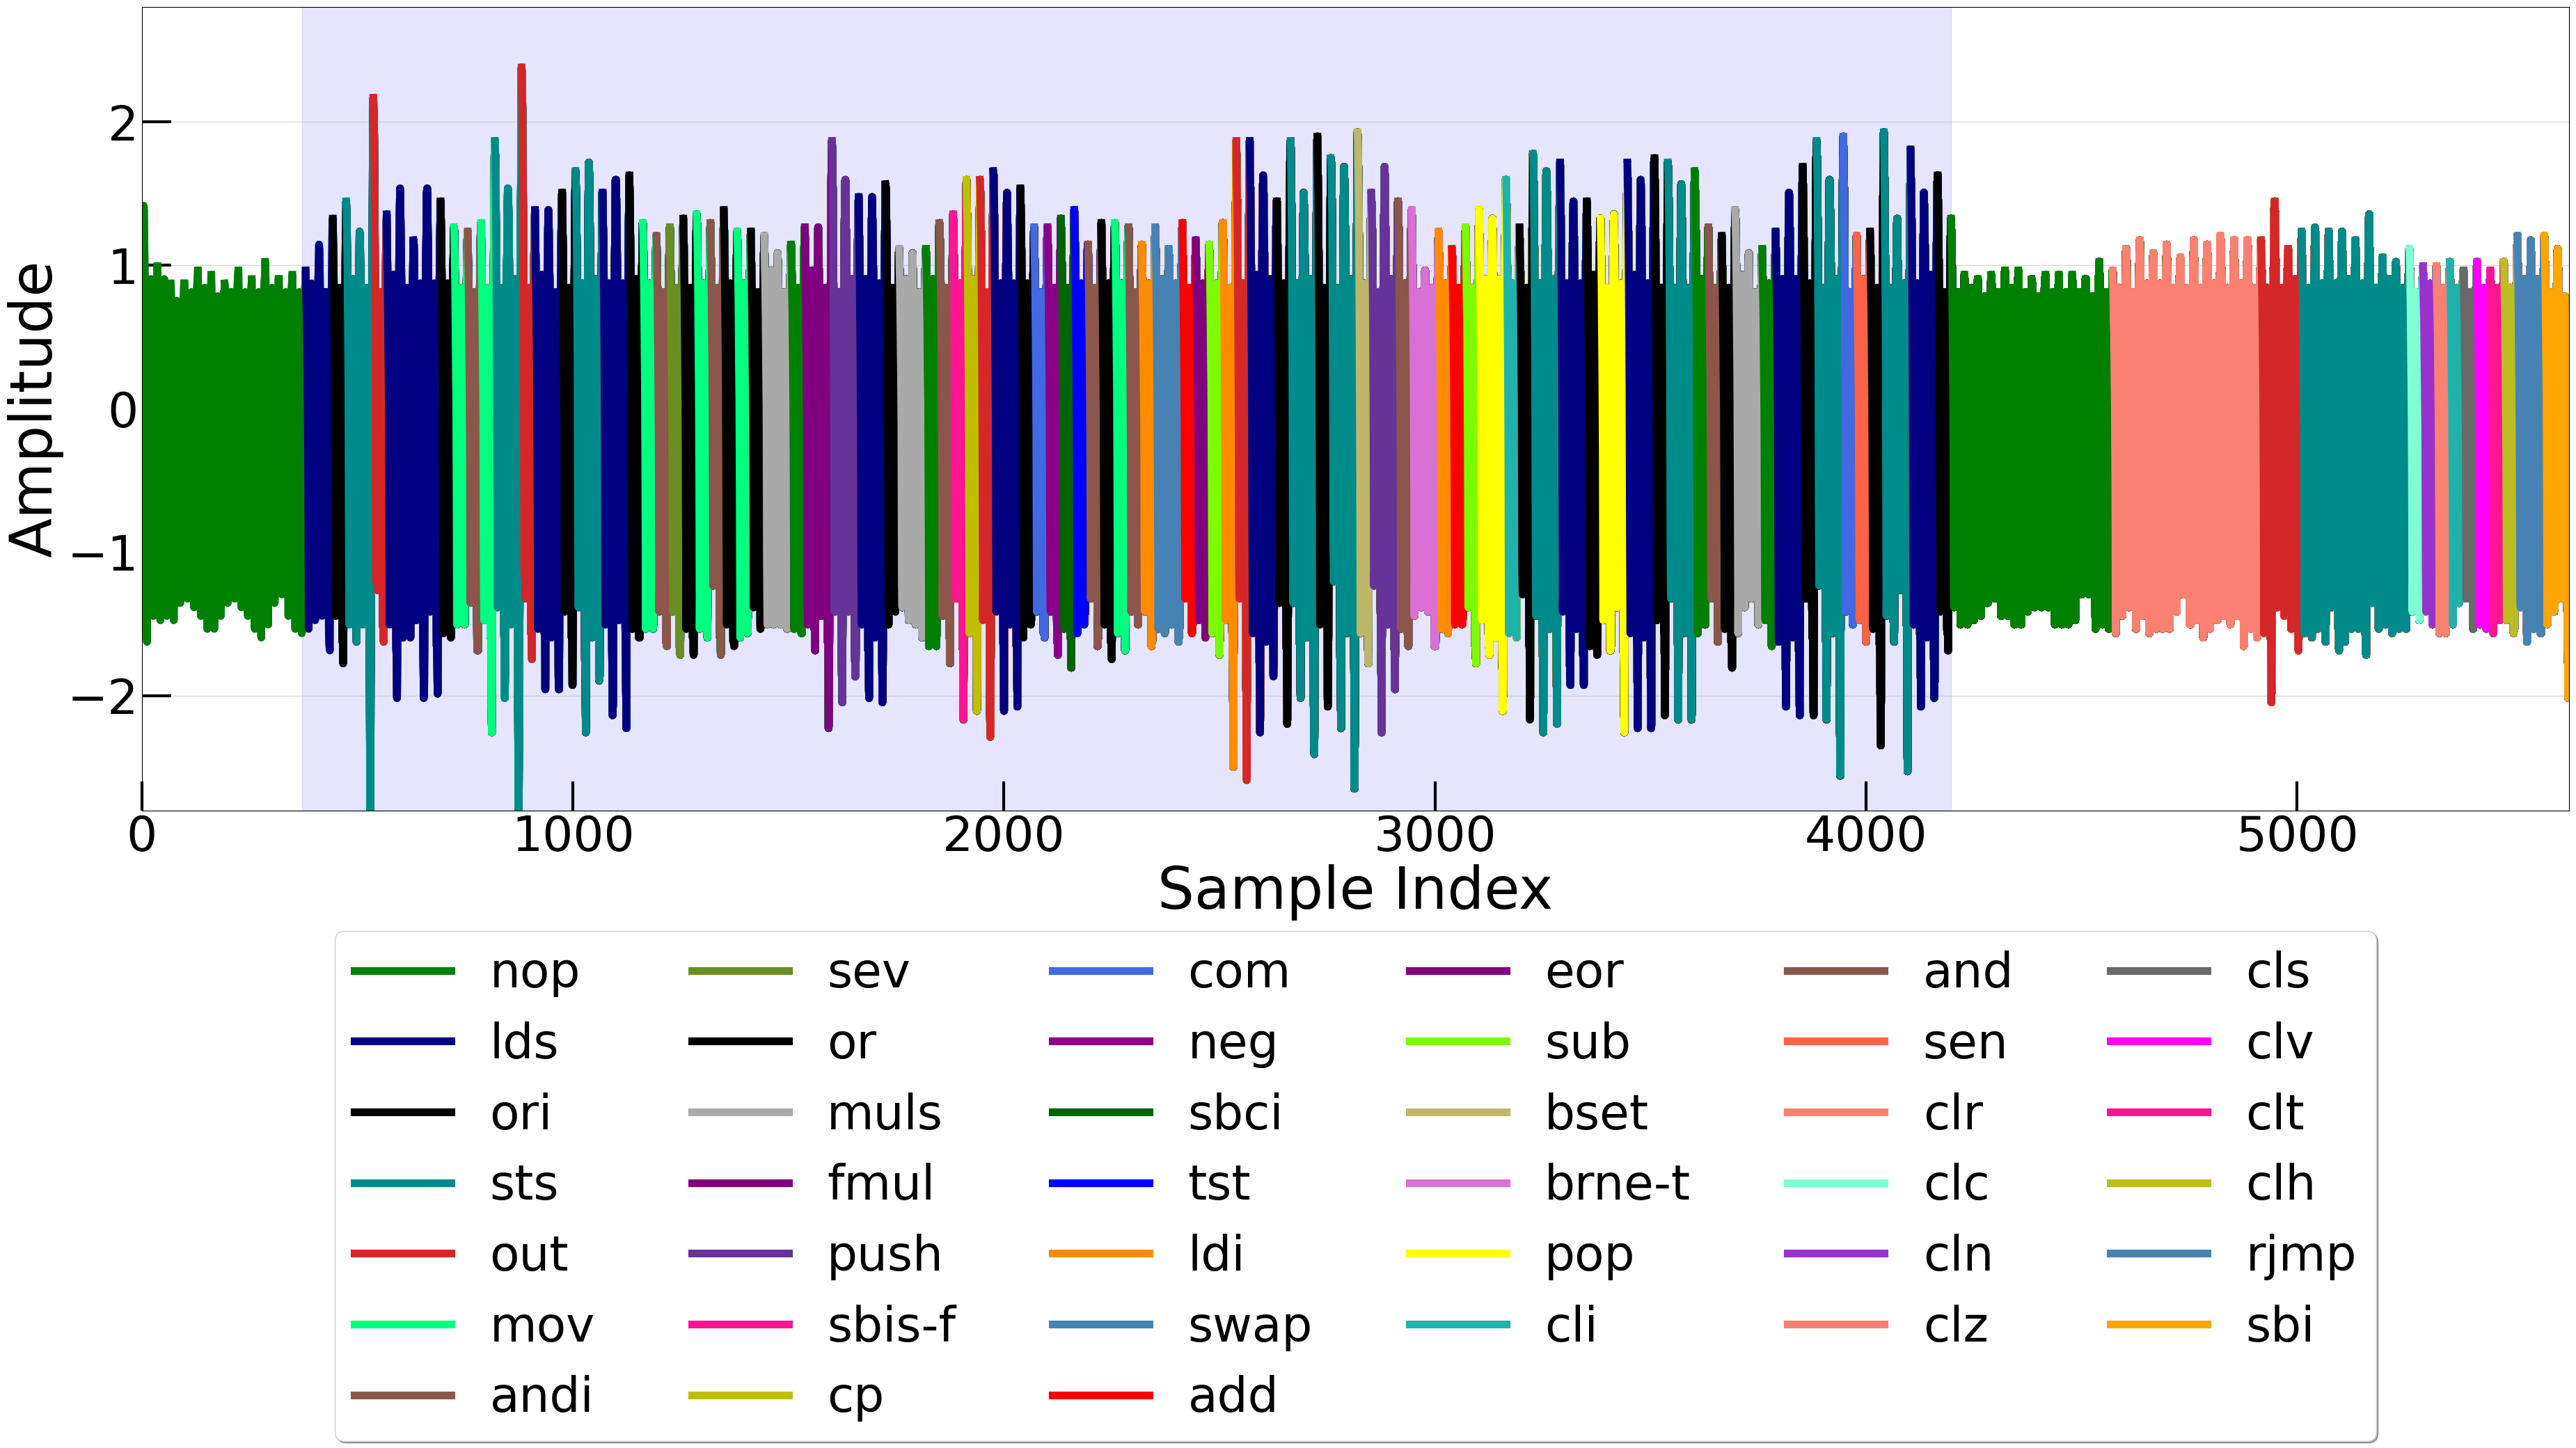

In [15]:
mid_code = TS_Program_2

code = start_code + mid_code + end_code

Signal = TS_2[test_loc]

time_Signal = np.arange(Signal.shape[0])
plt.plot(time_Signal, Signal)
MapTool.mapCodeSignal(Signal, code, pad)
plt.axvspan(MapTool.getPeaksLoc(Signal, pad, 24, False), MapTool.getPeaksLoc(Signal, pad, 268), color='blue', alpha=0.1)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True, ncol=6)
plt.xlim([0,len(Signal)])
plt.ylim(y_low,y_high)
#plt.savefig(save_folder + "Alpha_segment.png", bbox_inches='tight')
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.show()
plt.close()

## TS_3

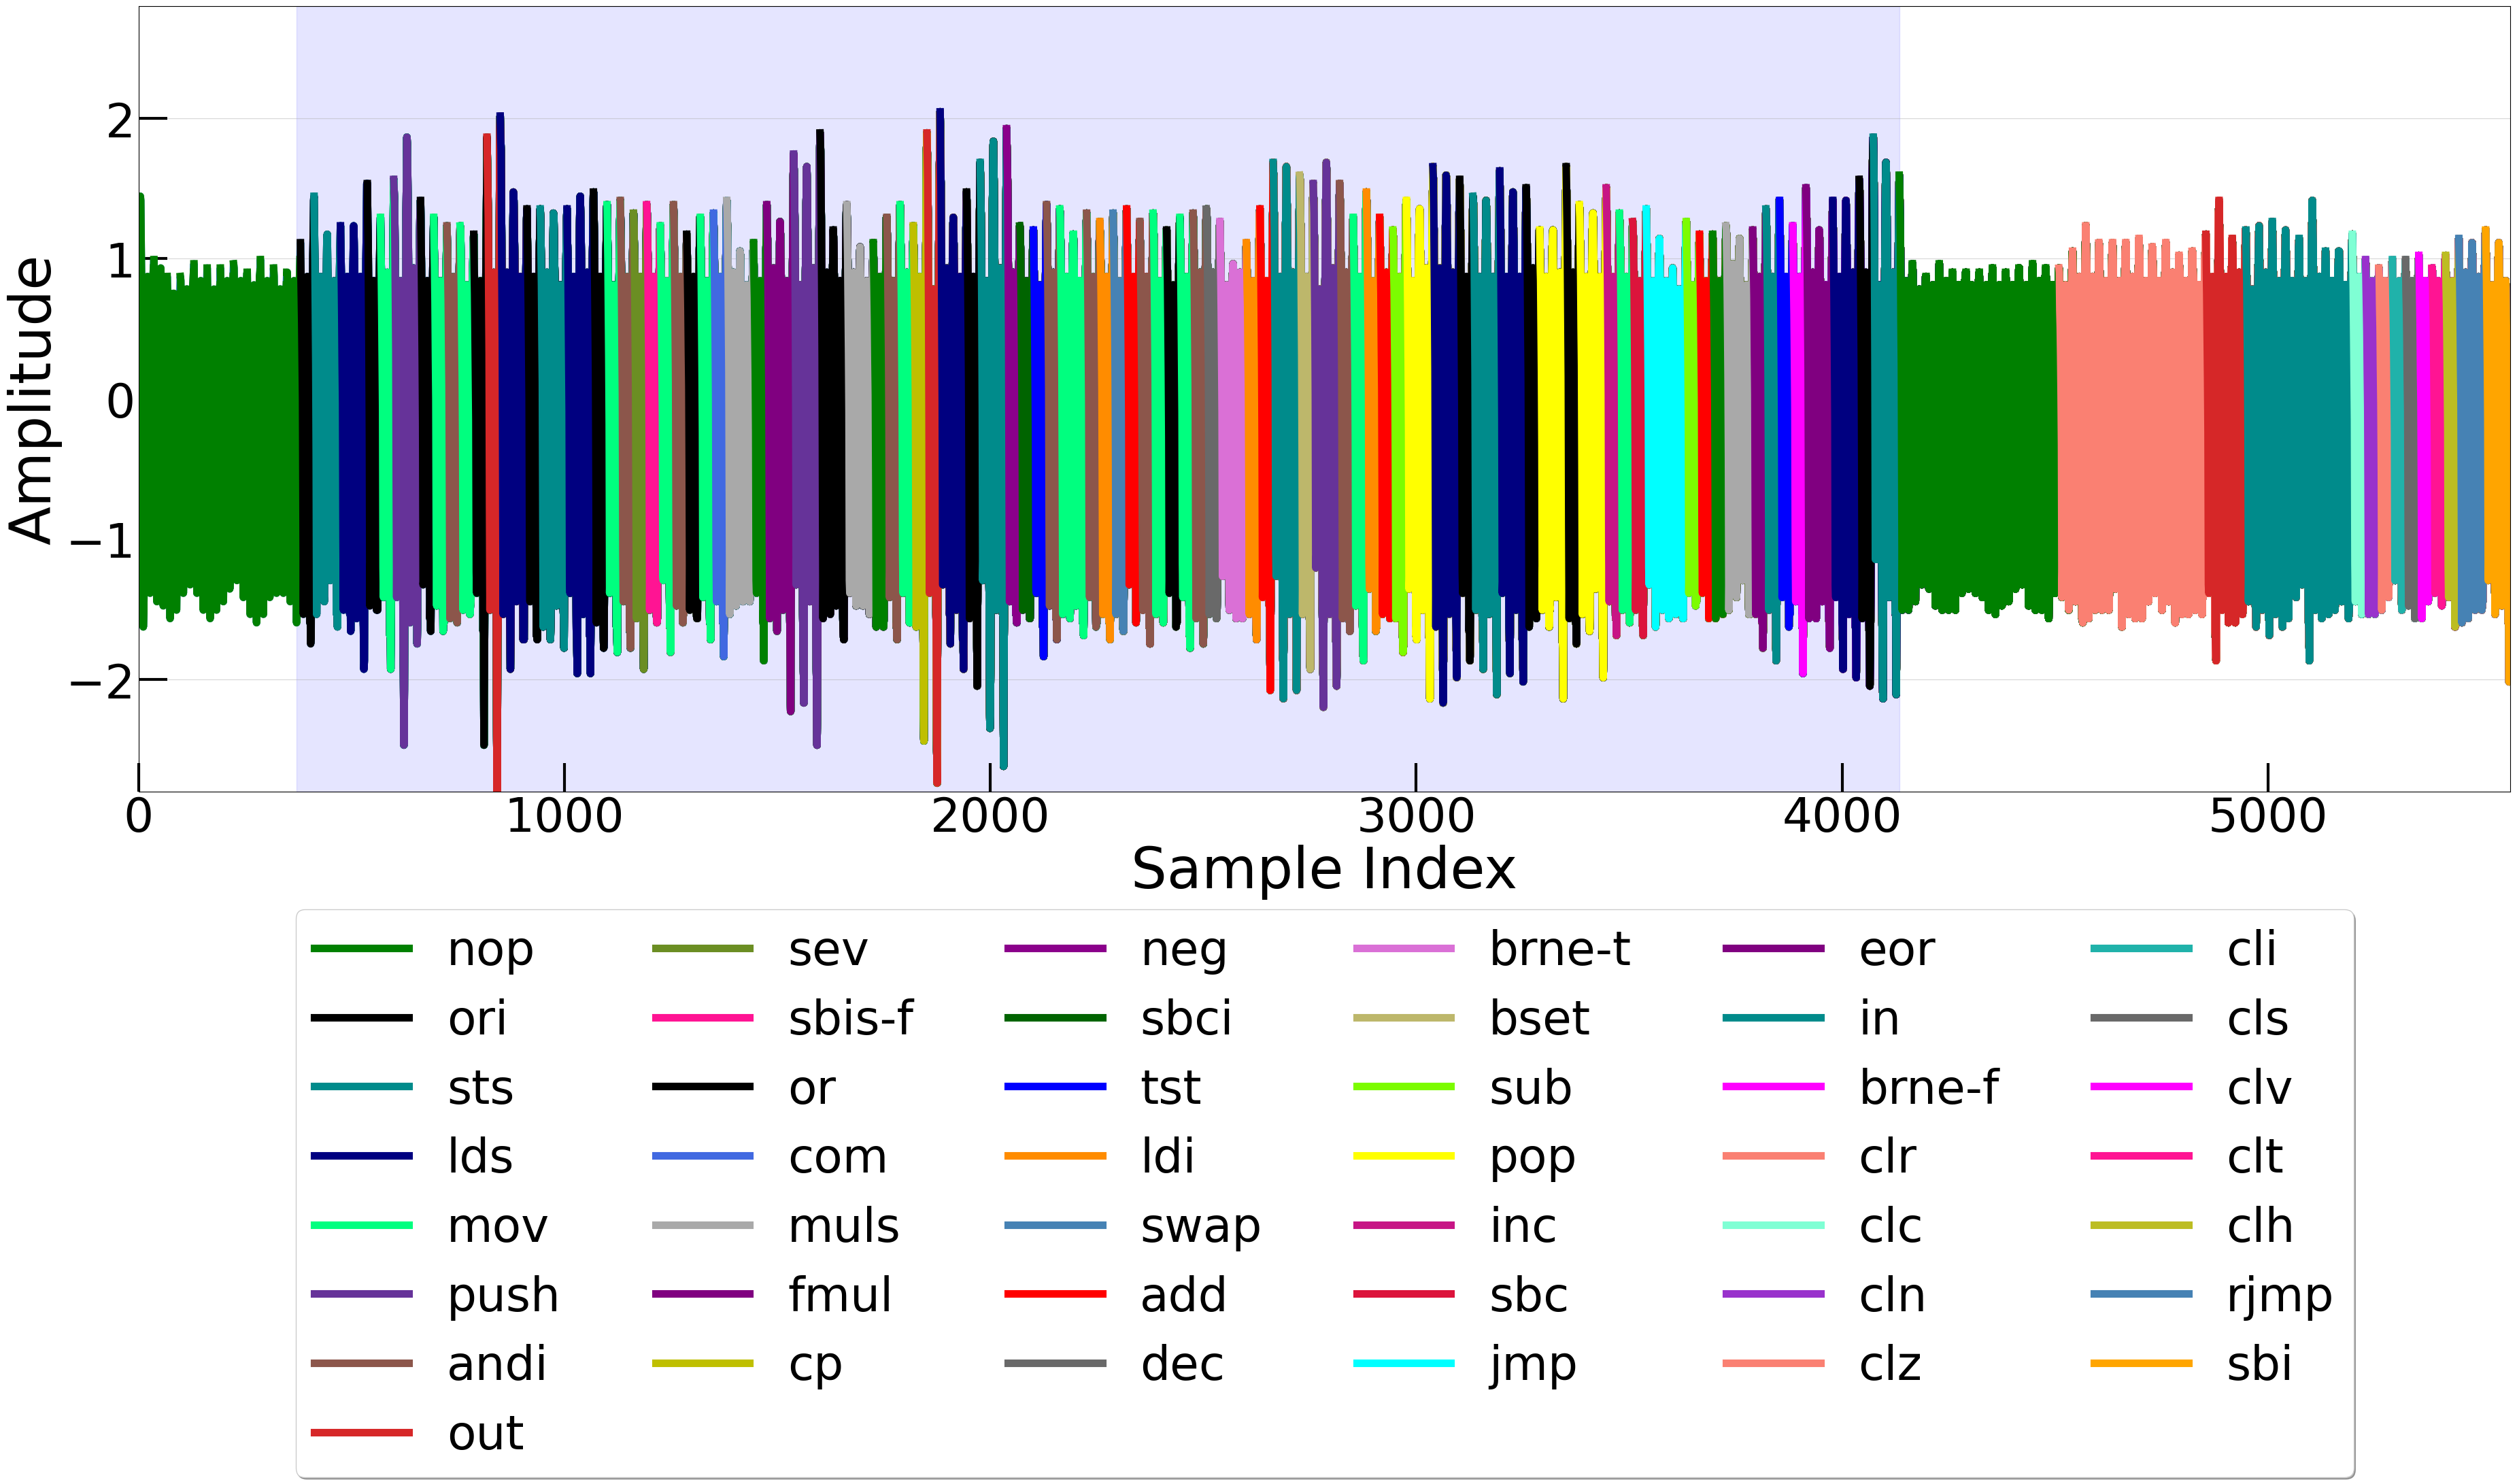

In [16]:
mid_code = TS_Program_3

code = start_code + mid_code + end_code

Signal = TS_3[test_loc]

time_Signal = np.arange(Signal.shape[0])
plt.plot(time_Signal, Signal)
MapTool.mapCodeSignal(Signal, code, pad)
plt.axvspan(MapTool.getPeaksLoc(Signal, pad, 24, False), MapTool.getPeaksLoc(Signal, pad, 264), color='blue', alpha=0.1)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True, ncol=6)
plt.xlim([0,len(Signal)])
plt.ylim(y_low,y_high)
#plt.savefig(save_folder + "Alpha_segment.png", bbox_inches='tight')
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.show()
plt.close()

## TS_4

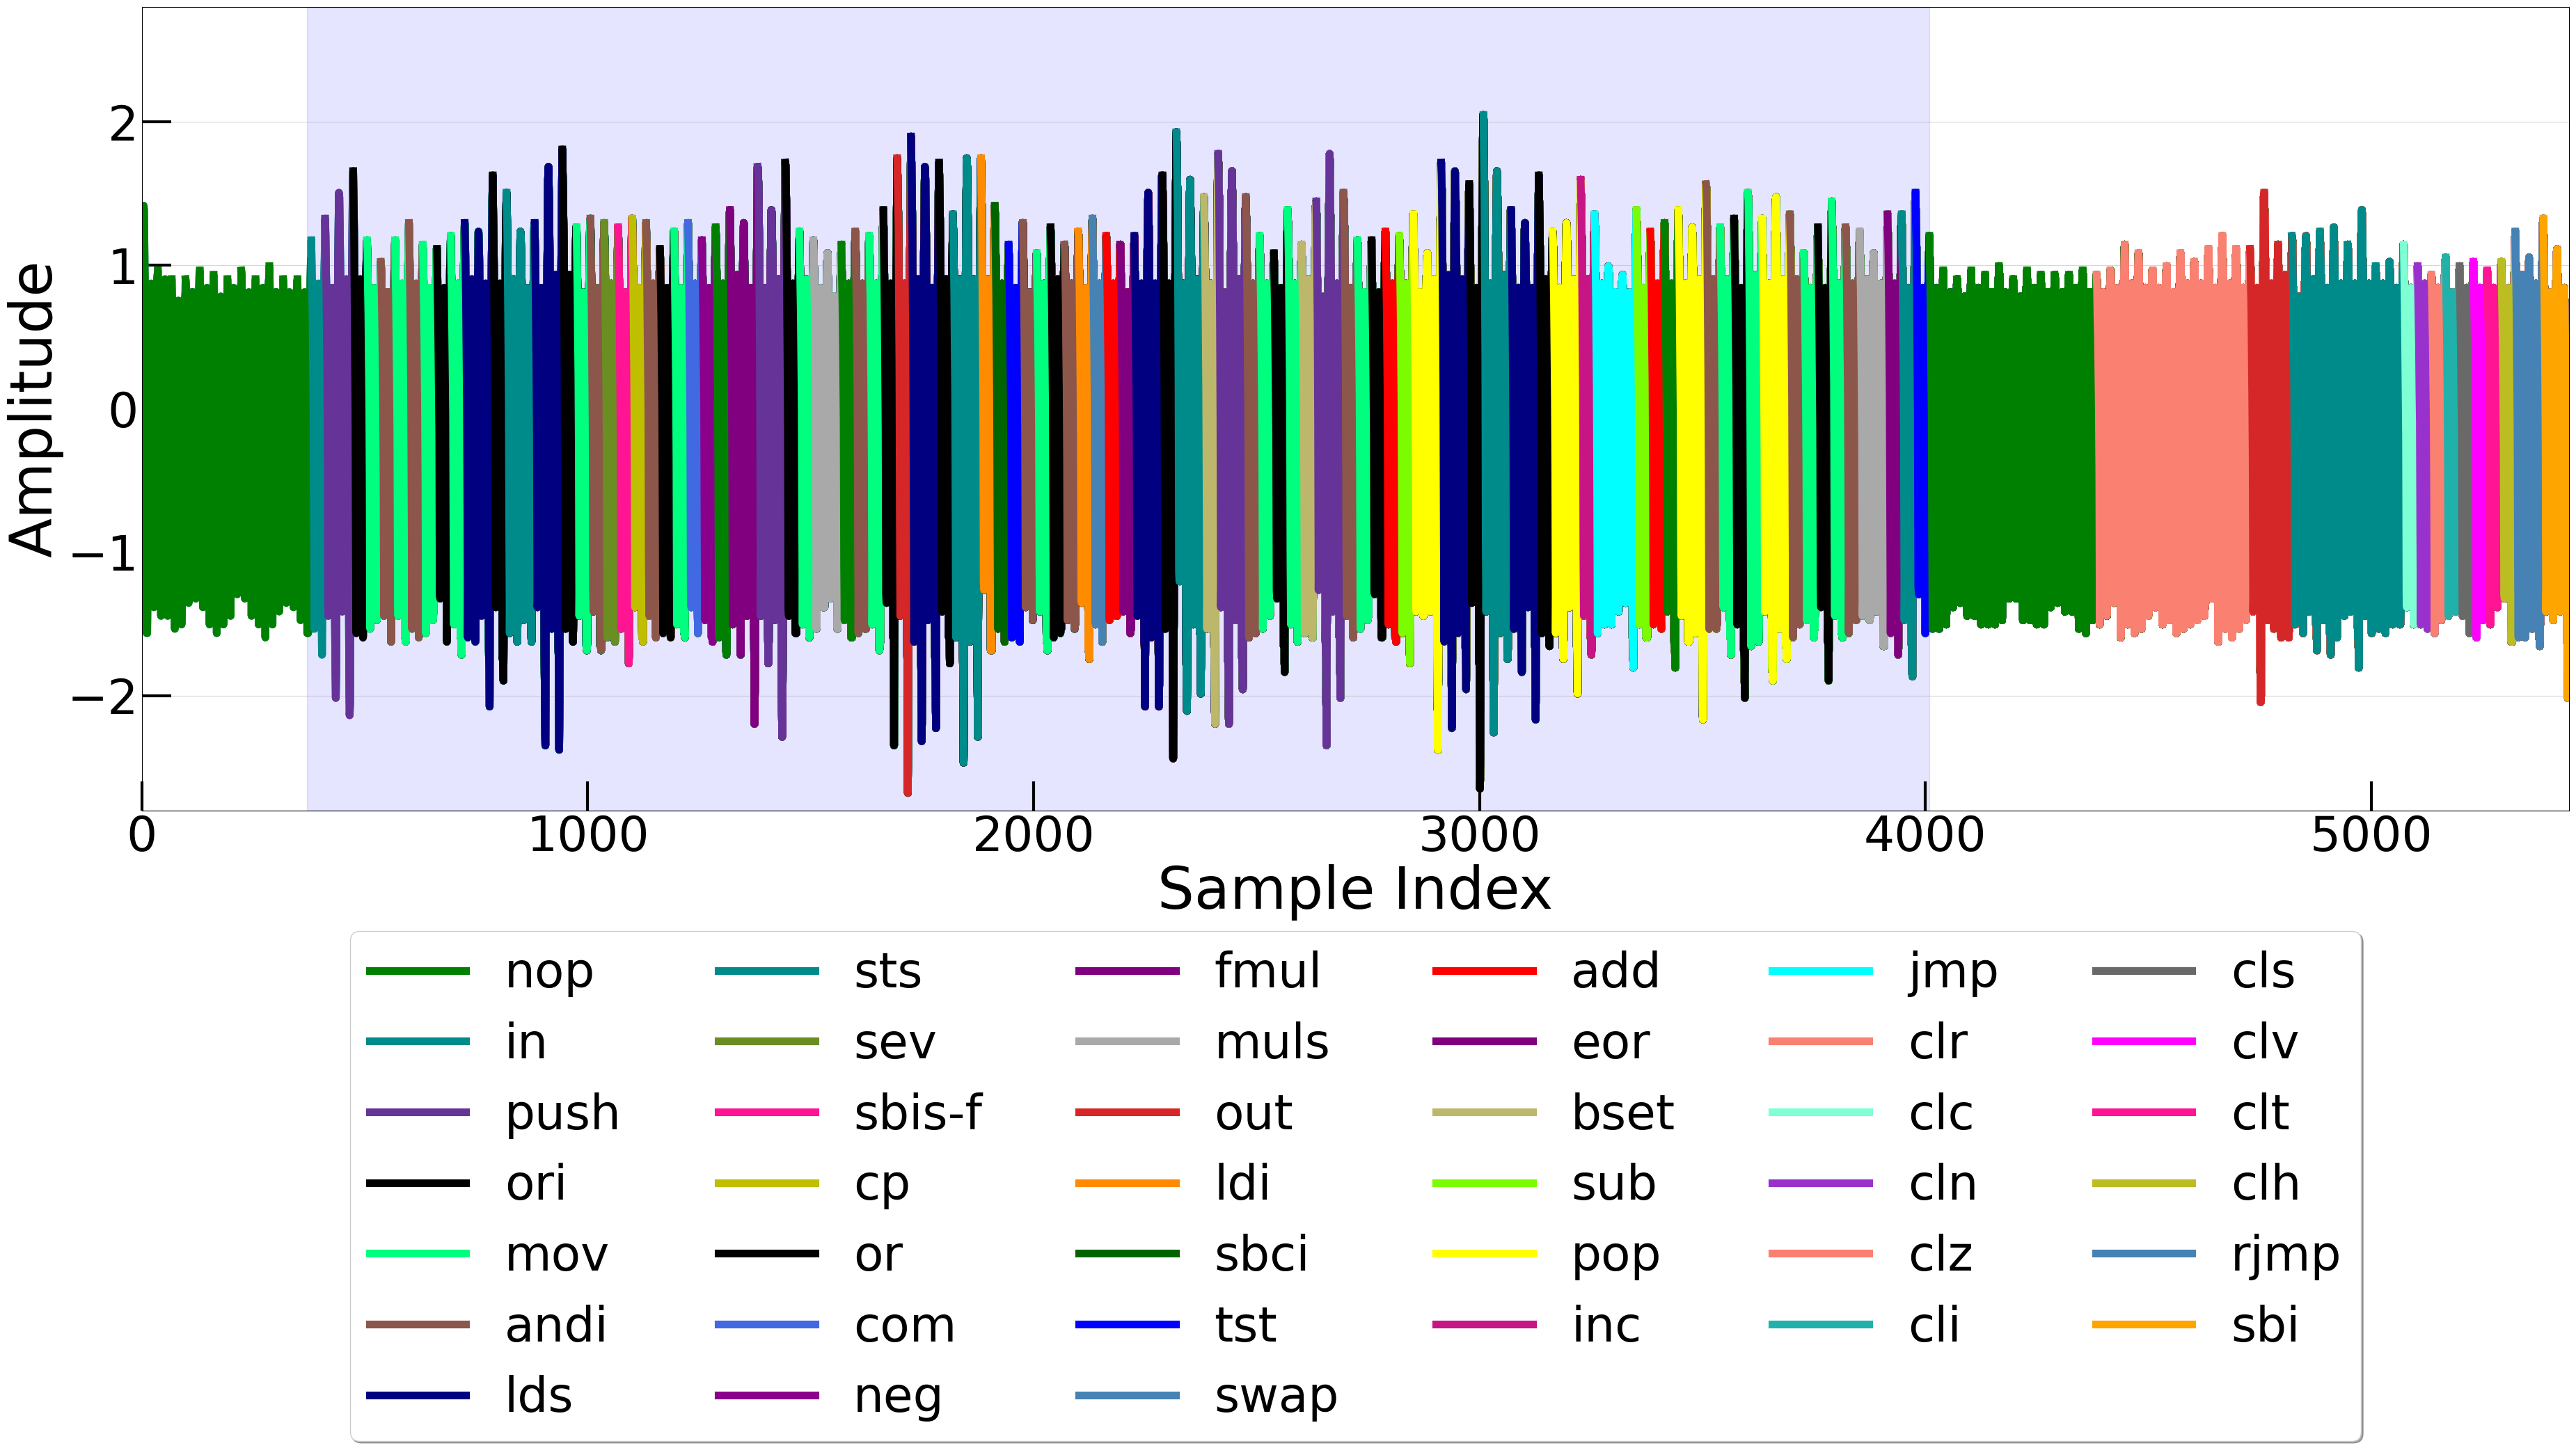

In [17]:
mid_code = TS_Program_4

code = start_code + mid_code + end_code

Signal = TS_4[test_loc]

time_Signal = np.arange(Signal.shape[0])
plt.plot(time_Signal, Signal)
MapTool.mapCodeSignal(Signal, code, pad)
plt.axvspan(MapTool.getPeaksLoc(Signal, pad, 24, False), MapTool.getPeaksLoc(Signal, pad, 256), color='blue', alpha=0.1)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True, ncol=6)
plt.xlim([0,len(Signal)])
plt.ylim(y_low,y_high)
#plt.savefig(save_folder + "Alpha_segment.png", bbox_inches='tight')
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.show()
plt.close()

## TS_5

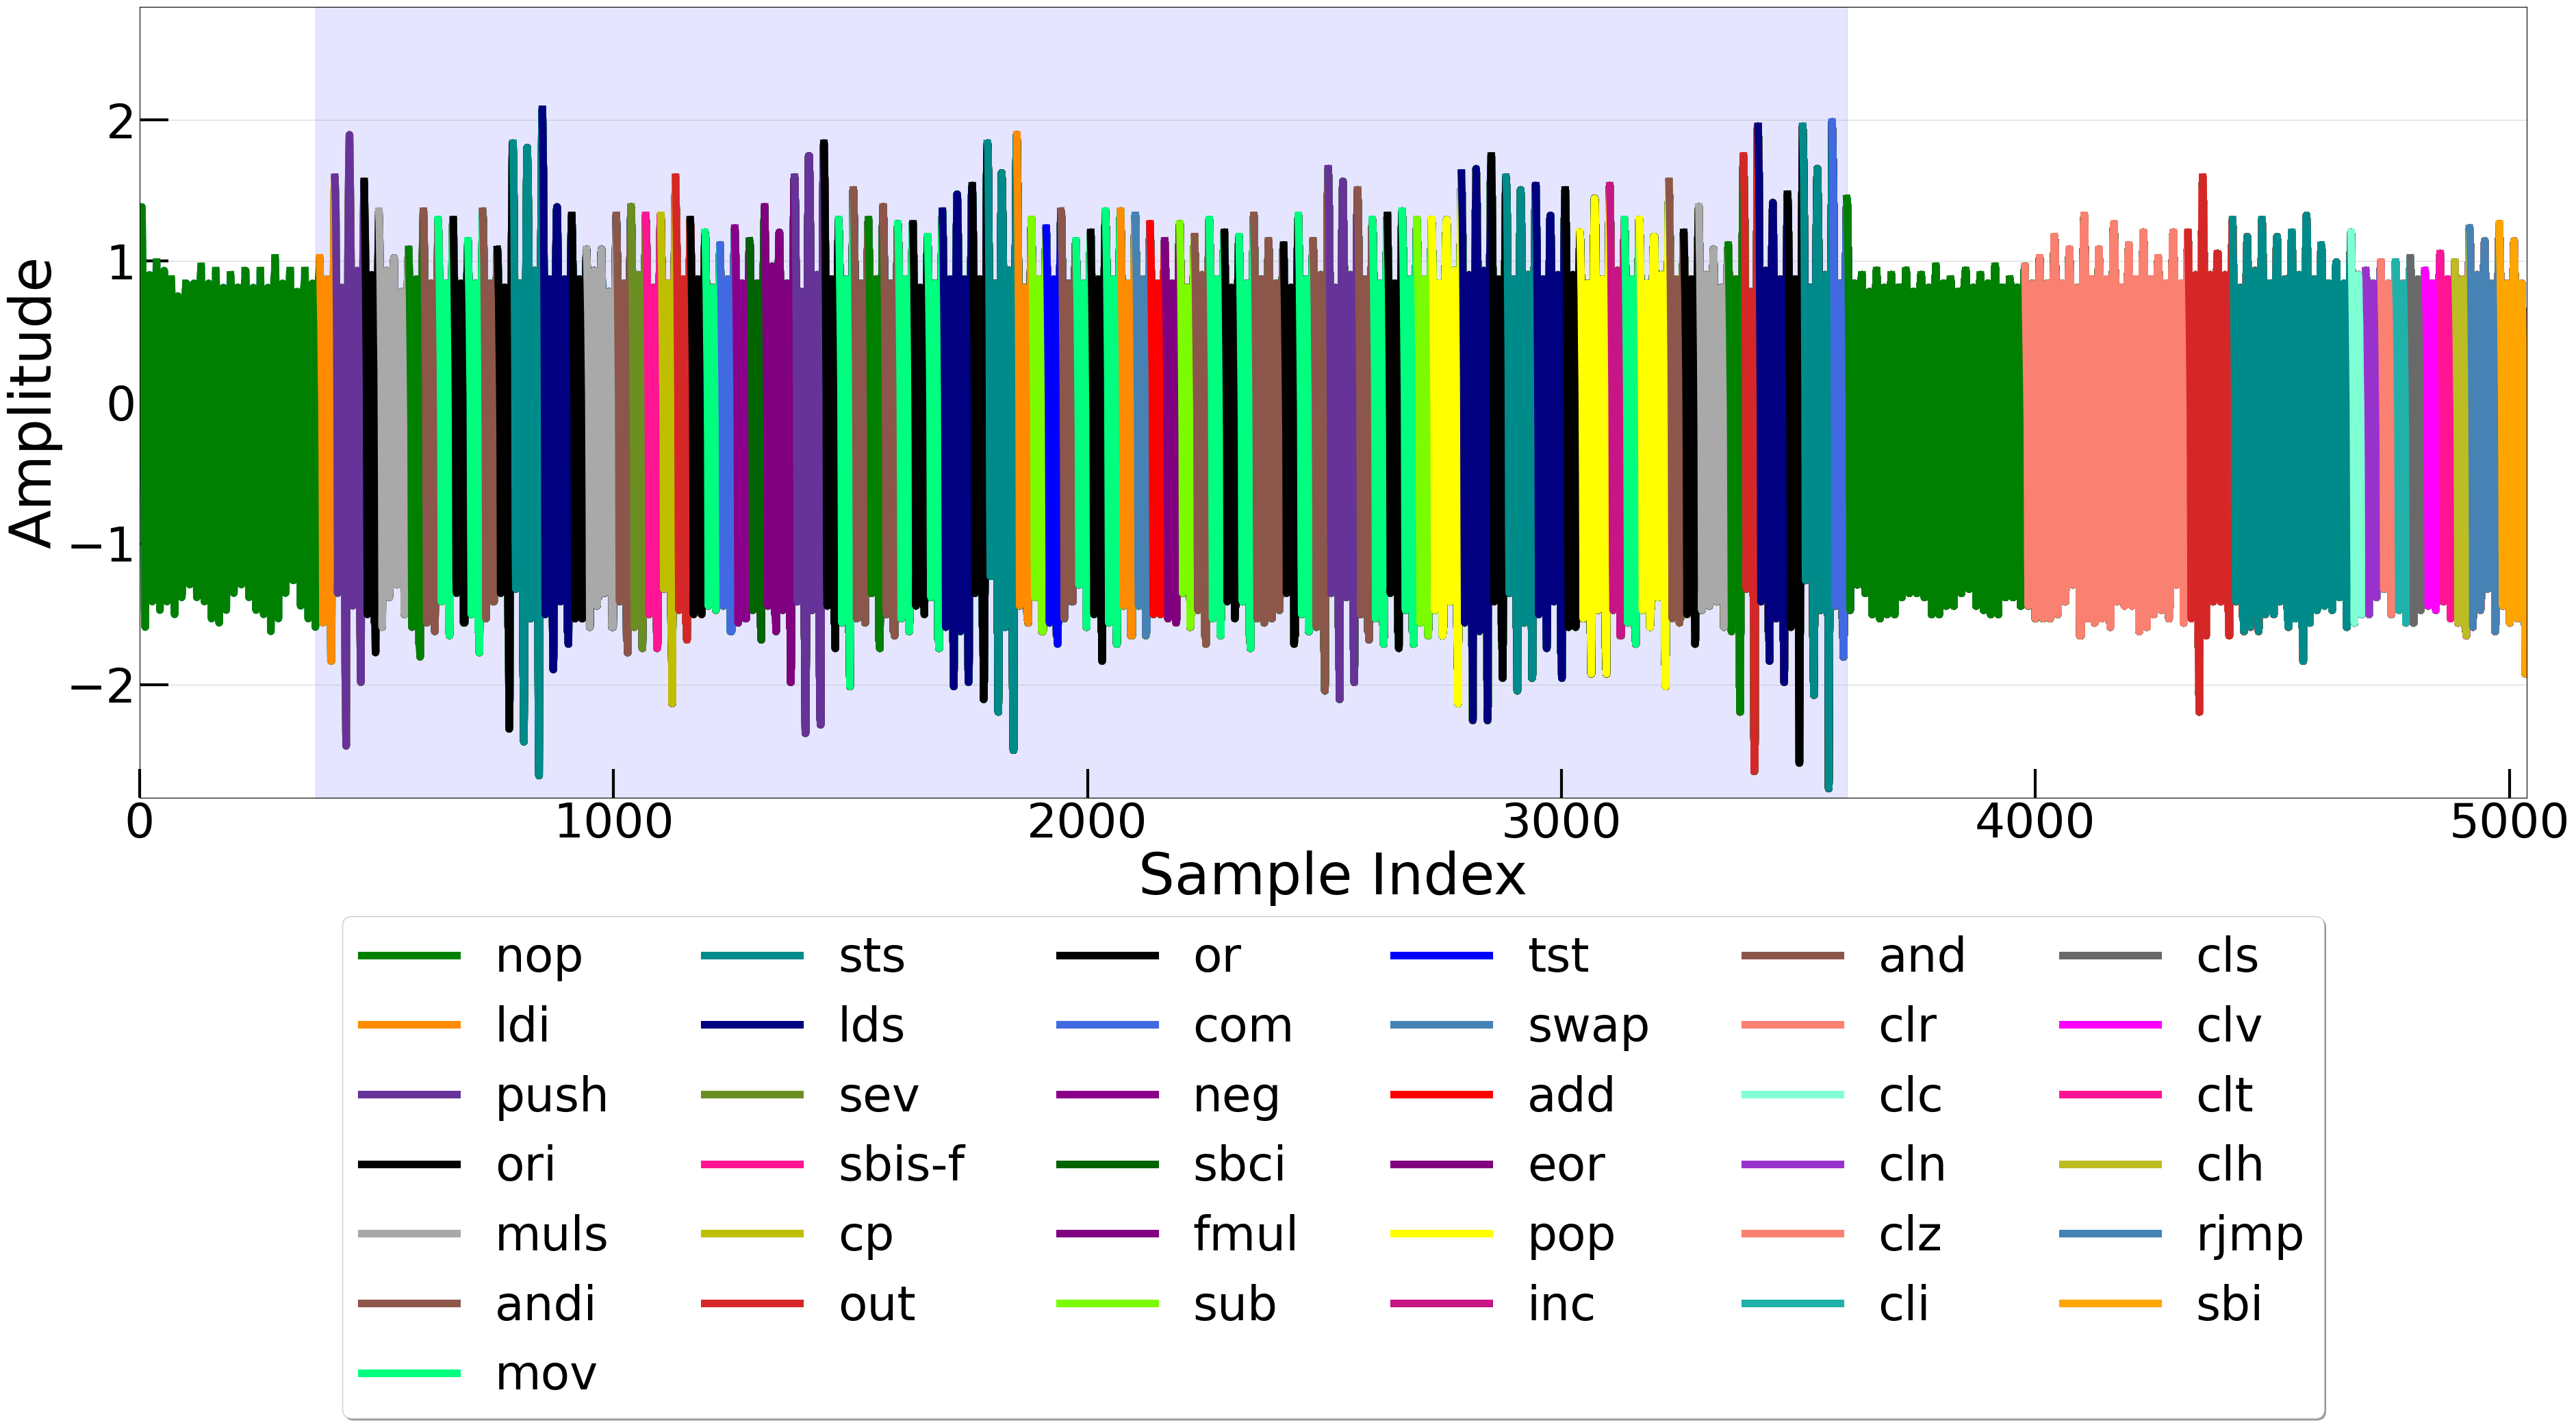

In [18]:
mid_code = TS_Program_5

code = start_code + mid_code + end_code

Signal = TS_5[test_loc]

time_Signal = np.arange(Signal.shape[0])
plt.plot(time_Signal, Signal)
MapTool.mapCodeSignal(Signal, code, pad)
plt.axvspan(MapTool.getPeaksLoc(Signal, pad, 24, False), MapTool.getPeaksLoc(Signal, pad, 230), color='blue', alpha=0.1)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True, ncol=6)
plt.xlim([0,len(Signal)])
plt.ylim(y_low,y_high)
#plt.savefig(save_folder + "Alpha_segment.png", bbox_inches='tight')
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.show()
plt.close()

# Create the code for the sequences

## Base ASM Code

In [14]:
TS_1_Base_Code = np.array(["ori", "sts", "lds", "ori", "mov",
              
              "andi",
              "ori", "sts", "out", "lds", "ori",
              "sts", "lds", "ori", "mov", "andi",
              "push", "ori", "mov", "andi", "or",
              "push", "ori", "muls", "nop", "fmul",
              
              "pop",
              
              "sts", "lds", "ori", "muls", "nop",
              "sev", "sbis-f", "cp", "out", "lds",
              "mov", "com", "neg", "sbci", "tst",
              "push", "ori", "mov", "andi", "ldi",
             
              "pop",
                         
              "out", "lds", "ori", "sts",
              "cp", "brpl-f", "cli", "ori", "sts",
                         
              "lds", "ori", "sts", "bset", "push",
              "dec", "brne-t", "ldi", "add", "sub",
              "brpl-f", "cli", "ori", "sts", "lds",
                         
              "andi", "mov", "ori", "mov",
              "andi", "ori", "muls", "nop", "pop",
              
              "pop",
                         
              "ori", "sts", "ldi", "sub",
              "cln", "lds", "ori", "sts"           
              ])

TS_2_Base_Code = np.array(["lds", "ori", "sts", "out", "lds",
              
              "lds", "ori", "mov", "andi", "mov",
              "sts", "out", "lds", "ori", "sts",
              "lds", "ori", "mov", "andi", "sev",
              "ori", "mov", "andi", "or", "mov",
              "ori", "muls", "nop", "fmul", "push",
                         
              "lds", "ori", "muls", "nop", "andi",
              "sbis-f", "cp", "out", "lds", "ori",
              "com", "neg", "sbci", "tst", "andi",
              "ori", "mov", "andi", "ldi", "swap",
                         
              "swap", "add", "eor", "sub",
              "ldi", "out", "lds", "ori", "sts",
                         
              "ori", "sts", "bset", "push", "andi",
              "brne-t", "ldi", "add", "sub", "pop",
              "cli", "ori", "sts", "lds", "ori", 
              
              "pop", "lds", "ori", "sts",
              "nop", "and", "ori", "muls", "nop",
                         
              "lds", "ori", "sts", "com",
              "sen", "ori", "sts", "lds", "ori"           
              ])

TS_3_Base_Code = np.array(["ori", "sts", "lds", "ori", "mov", 
              
              "push",
                         
              "ori", "mov", "andi", "mov", "ori",
              "out", "lds", "ori", "sts", "lds",
              "ori", "mov", "andi", "sev", "sbis-f",
              "mov", "andi", "or", "mov", "com",
              "muls", "nop", "fmul", "push", "ori",
              
              "ori", "muls", "nop", "andi", "mov",
              "cp", "out", "lds", "ori", "sts",
              "neg", "sbci", "tst", "andi", "mov",
              "mov", "andi", "ldi", "swap", "add",
                         
              "andi", "mov", "ori", "mov",
              "andi", "dec", "brne-t", "ldi", "add",
                         
              "sts", "bset", "push", "andi", "mov",
              "ldi", "add", "sub", "pop", "lds",
              "ori", "sts", "lds", "ori", "pop",
                         
              "ori", "pop", "inc", "mov",
              "sbc", "jmp", "sub", "add", "nop",
                         
              "muls", "eor", "in", "tst",
              "brne-f", "fmul", "lds", "ori", "sts"           
              ])

TS_4_Base_Code = np.array(["in", "push", "ori", "mov", "andi", 
                         
              "mov", "andi", "mov", "ori", "mov",
              "lds", "ori", "sts", "lds", "ori",
              "mov", "andi", "sev", "sbis-f", "cp", 
              "andi", "or", "mov", "com", "neg",
              "nop", "fmul", "push", "ori", "mov",
               
              "muls", "nop", "andi", "mov", "ori",
              "out", "lds", "ori", "sts", "ldi",
              "sbci", "tst", "andi", "mov", "ori",
              "andi", "ldi", "swap", "add", "eor",
                         
              "lds", "ori", "sts", "bset",
              "push", "andi", "mov", "ori", "mov",
                         
              "bset", "push", "andi", "mov", "ori",
              "add", "sub", "pop", "lds", "ori",
              "sts", "lds", "ori", "pop", "inc",
                         
              "jmp", "sub", "add", "nop",
              "pop", "andi", "mov", "ori", "mov",
              
              "pop",           
              
              "andi", "mov", "ori", "mov",
              "andi", "muls", "eor", "in", "tst",           
              ])

TS_5_Base_Code = np.array(["ldi", "push", "ori", "muls", "nop", 
                         
              "andi", "mov", "ori", "mov", "andi",
              "ori", "sts", "lds", "ori", "muls",
              "andi", "sev", "sbis-f", "cp", "out",
              "or", "mov", "com", "neg", "sbci",
              "fmul", "push", "ori", "mov", "andi",
              
              "nop", "andi", "mov", "ori", "mov",
              "lds", "ori", "sts", "ldi", "sub",
              "tst", "andi", "mov", "ori", "mov",
              "ldi", "swap", "add", "eor", "sub",
               
              "andi", "mov", "ori", "mov",           
              "andi", "andi", "ori", "mov", "andi",
              
              "push", "andi", "mov", "ori", "mov",           
              "sub", "pop", "lds", "ori", "sts",           
              "lds", "ori", "pop", "inc", "mov",
              
              "pop",
                         
              "and", "ori", "muls", "nop",
              "out", "lds", "ori", "sts", "com"           
              ])

In [15]:
'''
Simply adds the number of nops to the array
'''
def addNops(number, array):
    code_list = []
    count = 0
    while count < number:
        code_list.append('nop')
        count = count+1
    
    for code in array:
        code_list.append(code)
    return np.array(code_list)

In [16]:
TS_1_3_Seq = addNops(2, TS_1_Base_Code)
TS_2_3_Seq = addNops(2, TS_2_Base_Code)
TS_3_3_Seq = addNops(2, TS_3_Base_Code)
TS_4_3_Seq = addNops(2, TS_4_Base_Code)
TS_5_3_Seq = addNops(2, TS_5_Base_Code)

In [17]:
TS_1_4_Seq = addNops(3, TS_1_Base_Code)
TS_2_4_Seq = addNops(3, TS_2_Base_Code)
TS_3_4_Seq = addNops(3, TS_3_Base_Code)
TS_4_4_Seq = addNops(3, TS_4_Base_Code)
TS_5_4_Seq = addNops(3, TS_5_Base_Code)

In [18]:
TS_1_5_Seq = addNops(4, TS_1_Base_Code)
TS_2_5_Seq = addNops(4, TS_2_Base_Code)
TS_3_5_Seq = addNops(4, TS_3_Base_Code)
TS_4_5_Seq = addNops(4, TS_4_Base_Code)
TS_5_5_Seq = addNops(4, TS_5_Base_Code)

In [19]:
print(TS_1_5_Seq)

['nop' 'nop' 'nop' 'nop' 'ori' 'sts' 'lds' 'ori' 'mov' 'andi' 'ori' 'sts'
 'out' 'lds' 'ori' 'sts' 'lds' 'ori' 'mov' 'andi' 'push' 'ori' 'mov'
 'andi' 'or' 'push' 'ori' 'muls' 'nop' 'fmul' 'pop' 'sts' 'lds' 'ori'
 'muls' 'nop' 'sev' 'sbis-f' 'cp' 'out' 'lds' 'mov' 'com' 'neg' 'sbci'
 'tst' 'push' 'ori' 'mov' 'andi' 'ldi' 'pop' 'out' 'lds' 'ori' 'sts' 'cp'
 'brpl-f' 'cli' 'ori' 'sts' 'lds' 'ori' 'sts' 'bset' 'push' 'dec' 'brne-t'
 'ldi' 'add' 'sub' 'brpl-f' 'cli' 'ori' 'sts' 'lds' 'andi' 'mov' 'ori'
 'mov' 'andi' 'ori' 'muls' 'nop' 'pop' 'pop' 'ori' 'sts' 'ldi' 'sub' 'cln'
 'lds' 'ori' 'sts']


## Code splitting multi-cycles instructions into individual cycles.

In [23]:
'''
Simply splits known multi cycle codes.
'''
def splitCode(array):
    code_list = []
    two_cycle_list = ["sts", "lds", "muls", "fmul", "push", "pop"]
    three_cycle_list = ["jmp"]
    for code in array:
        # check for hyphens
        if code == "brne-f":
            code_list.append("brneF")
        elif code == "brne-t":
            code_list.append("brneTPT1")
            code_list.append("brneTPT2")
        elif code == "brpl-f":
            code_list.append("brplF")
        elif code == "sbis-f":
            code_list.append("sbisF")
        
        # check for two cycles
        elif code in two_cycle_list:
            code_list.append(code + "PT1")
            code_list.append(code + "PT2")
            
        # check for thee cycles
        elif code in three_cycle_list:
            code_list.append(code + "PT1")
            code_list.append(code + "PT2")
            code_list.append(code + "PT3")
        
        else:
            code_list.append(code)
            
    return np.array(code_list)

In [24]:
TS_1_3_Seq_Split = splitCode(TS_1_3_Seq)
TS_2_3_Seq_Split = splitCode(TS_2_3_Seq)
TS_3_3_Seq_Split = splitCode(TS_3_3_Seq)
TS_4_3_Seq_Split = splitCode(TS_4_3_Seq)
TS_5_3_Seq_Split = splitCode(TS_5_3_Seq)

In [25]:
TS_1_4_Seq_Split = splitCode(TS_1_4_Seq)
TS_2_4_Seq_Split = splitCode(TS_2_4_Seq)
TS_3_4_Seq_Split = splitCode(TS_3_4_Seq)
TS_4_4_Seq_Split = splitCode(TS_4_4_Seq)
TS_5_4_Seq_Split = splitCode(TS_5_4_Seq)

In [26]:
TS_1_5_Seq_Split = splitCode(TS_1_5_Seq)
TS_2_5_Seq_Split = splitCode(TS_2_5_Seq)
TS_3_5_Seq_Split = splitCode(TS_3_5_Seq)
TS_4_5_Seq_Split = splitCode(TS_4_5_Seq)
TS_5_5_Seq_Split = splitCode(TS_5_5_Seq)

In [27]:
print(TS_1_5_Seq_Split)

['nop' 'nop' 'nop' 'nop' 'ori' 'stsPT1' 'stsPT2' 'ldsPT1' 'ldsPT2' 'ori'
 'mov' 'andi' 'ori' 'stsPT1' 'stsPT2' 'out' 'ldsPT1' 'ldsPT2' 'ori'
 'stsPT1' 'stsPT2' 'ldsPT1' 'ldsPT2' 'ori' 'mov' 'andi' 'pushPT1'
 'pushPT2' 'ori' 'mov' 'andi' 'or' 'pushPT1' 'pushPT2' 'ori' 'mulsPT1'
 'mulsPT2' 'nop' 'fmulPT1' 'fmulPT2' 'popPT1' 'popPT2' 'stsPT1' 'stsPT2'
 'ldsPT1' 'ldsPT2' 'ori' 'mulsPT1' 'mulsPT2' 'nop' 'sev' 'sbisF' 'cp'
 'out' 'ldsPT1' 'ldsPT2' 'mov' 'com' 'neg' 'sbci' 'tst' 'pushPT1'
 'pushPT2' 'ori' 'mov' 'andi' 'ldi' 'popPT1' 'popPT2' 'out' 'ldsPT1'
 'ldsPT2' 'ori' 'stsPT1' 'stsPT2' 'cp' 'brplF' 'cli' 'ori' 'stsPT1'
 'stsPT2' 'ldsPT1' 'ldsPT2' 'ori' 'stsPT1' 'stsPT2' 'bset' 'pushPT1'
 'pushPT2' 'dec' 'brneTPT1' 'brneTPT2' 'ldi' 'add' 'sub' 'brplF' 'cli'
 'ori' 'stsPT1' 'stsPT2' 'ldsPT1' 'ldsPT2' 'andi' 'mov' 'ori' 'mov' 'andi'
 'ori' 'mulsPT1' 'mulsPT2' 'nop' 'popPT1' 'popPT2' 'popPT1' 'popPT2' 'ori'
 'stsPT1' 'stsPT2' 'ldi' 'sub' 'cln' 'ldsPT1' 'ldsPT2' 'ori' 'stsPT1'
 'stsPT2']


# Method

In [28]:
'''
Return a dictionary of (A) datapoints from the end of the previous to the start of the next instruction surrounding each sequence
for all signals and (B) the names of the instuctions being executed in the sequence. I.E. {Data: [], Code: []}

Parameters
Signals: the signals to extract information from.
peakStart: the starting peak to start extracting information from.
peakEnd: the ending peak to extract information from.
code: string assembly code that is in the total sequence of code to extract from. Given in 1D numpy array
amount: amount of code to extract each time.
length: the amount of time indexs per sequence. (this is due to the fact that a certain limit will be necessary for the NN model)
skip: amount of code to skip each time. Default = 1.
'''
def extractSequences(signals, peakStart, peakEnd, code, amount, length, skip=1):
    # list object to contain the dictionry information.
    listOfInfo = []
    # cycle through the code sequences to extract
    for c in range(0, code.shape[0]-(amount-1), skip):
        # obtain the ASM code for the sequence.
        ## list object to contain the exact code of the sequence.
        seqCode =[]
        ## cycle through the amount of code in the sequence
        for i in range(amount):
            seqCode.append(code[c+i])
        ## Convert to numpy
        seqCode = np.array(seqCode)
        ## Obtain the amount of cycles in the sequenceCode
        ### Note for now we will use just the 1 cycle (2 peaks) for each instruction as this is an experiment.
        ### Later will need to identify which instructions cost more cycles and perform a lookup.
        amtOfCycles = 1*amount
        amtOfPeaks = amtOfCycles * 2
        amtOfPrior = 2
        step = c * (1*2)
        
        # Obtain the extracted sequences from the signals.
        seqs = []
        ## cycle through each signal
        for s in range(signals.shape[0]):
            ## extract the sequence
            ## This sequence will be from the low peak before the sequence to the high peak after the sequence.
            seq = signals[s][MapTool.getPeaksLoc(signals[s], pad, step+peakStart, False): MapTool.getPeaksLoc(signals[s], pad, step+peakStart+amtOfPeaks)]
            ## now that we have the sequnce, we need to cut equally from both ends to the size necessary,
            ## This will give the best chance to avoid removing data from what we will be extracting from the
            ## synthetic example. I.E. from 0 value before and after code sequence.
            seq = refitSignal(seq, length)
            seqs.append(seq)
        
        seqs = np.array(seqs)
        # Create a dictionary item pair of code and sequecnes.
        dictPair = {"Seq": seqs, "Code": seqCode}
        listOfInfo.append(dictPair)
    
    return listOfInfo

In [29]:
'''
This method cuts the dataset down to the desired size by removing equal parts from both sides. 
(front will take out more if necessary).
signal: the signal to cut from.
length: the length that the signal needs to be.
'''
def refitSignal(signal, length):
    # Identify how many to remove
    currentSize = signal.shape[0]
    removeCount = currentSize - length
    # Check to see if it is possible to remove that many.
    if removeCount < 0:
        print("ERROR: size is set to be to large, readjust to at least: " + str(currentSize))
        return signal
    else:
        # flip from removing beginning or end of signal to remove data from.
        front = True
        tempSignal = np.copy(signal)
        while removeCount > 0:
            if front == True:
                # take from beginning
                tempSignal = tempSignal[1:]
                removeCount = removeCount - 1
                front == False
            else:
                # take from end
                tempSignal = tempSignal[:tempSignal.shape[0]-2]
                removeCount = removeCount-1
                front == True
        return tempSignal

In [30]:
'''
This will give the list of lengths that is seen for the desired sequences.
This is used to determine the optimal length for the sequences which must be the same and all sequnces bust be
able to contain that much information.
'''
def extractSequencesFindLimit(signals, peakStart, peakEnd, code, amount, skip=1):
    # list object to contain the dictionry information.
    listOfInfo = []
    # cycle through the code sequences to extract
    for c in range(0, code.shape[0]-(amount-1), skip):
        # obtain the ASM code for the sequence.
        ## list object to contain the exact code of the sequence.
        seqCode =[]
        ## cycle through the amount of code in the sequence
        for i in range(amount):
            seqCode.append(code[c+i])
        ## Convert to numpy
        seqCode = np.array(seqCode)
        ## Obtain the amount of cycles in the sequenceCode
        ### Note for now we will use just the 1 cycle (2 peaks) for each instruction as this is an experiment.
        ### Later will need to identify which instructions cost more cycles and perform a lookup.
        amtOfCycles = 1*amount
        amtOfPeaks = amtOfCycles * 2
        amtOfPrior = 2
        step = c * (1*2)
        
        tempLimits = []
        # Obtain the extracted sequences from the signals.
        ## cycle through each signal
        for s in range(signals.shape[0]):
            ## extract the sequence
            ## This sequence will be from the low peak before the sequence to the high peak after the sequence.
            seq = signals[s][MapTool.getPeaksLoc(signals[s], pad, step+peakStart, False): MapTool.getPeaksLoc(signals[s], pad, step+peakStart+amtOfPeaks)]
            #print(seq)
            ## now that we have the sequnce, we need to cut equally from both ends to the size necessary,
            ## This will give the best chance to avoid removing data from what we will be extracting from the
            ## synthetic example. I.E. from 0 value before and after code sequence.
            tempLimit = seq.shape[0]
            #if tempLimit < 135:
                #print(s)
            tempLimits.append(tempLimit)
        
        tempLimits = np.array(tempLimits)
        # Create a dictionary item pair of code and sequecnes.
        #print("The unique lengths for sequence: ", seqCode)
        #print(np.unique(tempLimits))
        #print(tempLimits)
        listOfInfo.append(tempLimits)
    
    listOfInfo = np.array(listOfInfo)
    listOfInfo = listOfInfo.flatten()
    
    return listOfInfo

### As you can see the minimum signal for obtaining the sequence that we need is..
- 3 sequence: 98
- 4 sequence: 130
- 5 sequence: 161

In [31]:
limit_1_seq = 34
limit_3_seq = 98
limit_4_seq = 130
limit_5_seq = 161

# Now we have a method that will extract sequences, however many of the sequences obtained are repeats between other datasets.

- Create a method that will take all sets of EM signals and codes
    - extract the sequences and codes from each
    - Identify and combine like code
    - Return the code and sequences across all sets.

In [34]:
'''
This method will extract the sequences and code of the sequences for multiple sets of signals.
It will also combine the like code sequences together.

Parameters
signalSets: the signal sets given in a 3D numpy matrix
Codes: full code of the extrancting sequences for the signals, given in a 2D numpy matrix
peakStarts: the starting peak for each sets EM signal to extract from, given in a 2D numpy matrix
peakEnds: the ending peak for each sets EM signal to extract from, given in a 2D numpy matrix
amount: the amount of instructions per sequence.
skip: the amount to of instructions to skip by per sequence extraction.
'''
def extractSequencesDataset(signalSets, Codes, peakStarts, peakEnds, amount, skip=1, limit=0):
    # create a list of entire sequence information
    Info = []
    
    if limit == 0:
        print("Finding limit...")

        minilimit = 9999999999
        # identify the limit
        ## Obtain the information for one set
        for n in range(Codes.shape[0]):
            print("Working on Program: ", n)
            signals = signalSets[n]
            code = Codes[n]
            peakStart = peakStarts[n]
            peakEnd = peakEnds[n]

            # obtain the optimal limit for the set
            limits = extractSequencesFindLimit(signals, peakStart, peakEnd, code, amount)
            limit = limits.min()
            # Identify the best limit across all sets
            if limit < minilimit:
                minilimit = limit

        print("Limit Found! ", minilimit)
    
    else:
        minilimit = limit
        print("Limit set to: ", minilimit)
    
    print("Extracting sequences...")
    # identify the sequences and sequence codes.
    ## Obtain the information for one set
    for n in range(Codes.shape[0]):
        print("Working on Program: ", n)
        signals = signalSets[n]
        code = Codes[n]
        peakStart = peakStarts[n]
        peakEnd = peakEnds[n]
        
        # obtain the sequence and code sequences information for the set
        tempInfo = extractSequences(signals, peakStart, peakEnd, code, amount, minilimit)
        
        # cycle through each obtained info
        for tempinfo in tempInfo:
            #print(tempinfo["Code"])
            # check if Info is empty
            if len(Info) == 0:
                # add the instances of the obtained info to Info
                dictSeq = {"Seq": tempinfo["Seq"], "Code": tempinfo["Code"]}
                Info.append(dictSeq)
                #print("Check")
            else:
                # check if there is already an occures of the sequence code.
                foundInst = False
                for info in Info:
                    if np.array_equal(info["Code"], tempinfo["Code"]):
                        # concatentated the two sets of sequences as they are for the same code sequence.
                        info["Seq"] = np.concatenate((info["Seq"], tempinfo["Seq"]))
                        foundInst = True
                
                # if no already occures in Info list then add.
                if foundInst == False:
                    #print("Not Found")
                    # add the instances of the obtained info to Info
                    dictSeq = {"Seq": tempinfo["Seq"], "Code": tempinfo["Code"]}
                    Info.append(dictSeq)
                    
    return Info

# Code for getting only the peaks

In [35]:
'''
Return a dictionary of (A) datapoints from the end of the previous to the start of the next instruction surrounding each sequence
for all signals and (B) the names of the instuctions being executed in the sequence. I.E. {Data: [], Code: []}

Parameters
Signals: the signals to extract information from.
peakStart: the starting peak to start extracting information from.
peakEnd: the ending peak to extract information from.
code: string assembly code that is in the total sequence of code to extract from. Given in 1D numpy array
amount: amount of code to extract each time.
length: the amount of time indexs per sequence. (this is due to the fact that a certain limit will be necessary for the NN model)
skip: amount of code to skip each time. Default = 1.
'''
def extractSequences_Peaks(signals, peakStart, peakEnd, code, amount, length, skip=1):
    # list object to contain the dictionry information.
    listOfInfo = []
    # cycle through the code sequences to extract
    for c in range(0, code.shape[0]-(amount-1), skip):
        # obtain the ASM code for the sequence.
        ## list object to contain the exact code of the sequence.
        seqCode =[]
        ## cycle through the amount of code in the sequence
        for i in range(amount):
            seqCode.append(code[c+i])
        ## Convert to numpy
        seqCode = np.array(seqCode)
        ## Obtain the amount of cycles in the sequenceCode
        ### Note for now we will use just the 1 cycle (2 peaks) for each instruction as this is an experiment.
        ### Later will need to identify which instructions cost more cycles and perform a lookup.
        amtOfCycles = 1*amount
        amtOfPeaks = amtOfCycles * 2
        amtOfPrior = 2
        step = c * (1*2)
        
        # Obtain the extracted sequences from the signals.
        seqs = []
        ## cycle through each signal
        for s in range(signals.shape[0]):
            ## extract the sequence
            ## This sequence will be from the low peak before the sequence to the high peak after the sequence.
            seq = signals[s][MapTool.getPeaksLoc(signals[s], pad, step+peakStart, False): MapTool.getPeaksLoc(signals[s], pad, step+peakStart+amtOfPeaks-1)+1]
            ## now that we have the sequnce, we need to cut equally from both ends to the size necessary,
            ## This will give the best chance to avoid removing data from what we will be extracting from the
            ## synthetic example. I.E. from 0 value before and after code sequence.
            seq = MapTool.getPeaks(seq, pad)
            seqs.append(seq)
        
        seqs = np.array(seqs)
        # Create a dictionary item pair of code and sequecnes.
        dictPair = {"Seq": seqs, "Code": seqCode}
        listOfInfo.append(dictPair)
    
    return listOfInfo

In [36]:
'''
This method will extract the sequences and code of the sequences for multiple sets of signals.
It will also combine the like code sequences together.
This will get only the peaks

Parameters
signalSets: the signal sets given in a 3D numpy matrix
Codes: full code of the extrancting sequences for the signals, given in a 2D numpy matrix
peakStarts: the starting peak for each sets EM signal to extract from, given in a 2D numpy matrix
peakEnds: the ending peak for each sets EM signal to extract from, given in a 2D numpy matrix
amount: the amount of instructions per sequence.
skip: the amount to of instructions to skip by per sequence extraction.
'''
def extractSequencesDataset_Peaks(signalSets, Codes, peakStarts, peakEnds, amount, skip=1, limit=0):
    # create a list of entire sequence information
    Info = []
    
    if limit == 0:
        print("Finding limit...")

        minilimit = 9999999999
        # identify the limit
        ## Obtain the information for one set
        for n in range(Codes.shape[0]):
            print("Working on Program: ", n)
            signals = signalSets[n]
            code = Codes[n]
            peakStart = peakStarts[n]
            peakEnd = peakEnds[n]

            # obtain the optimal limit for the set
            limits = extractSequencesFindLimit(signals, peakStart, peakEnd, code, amount)
            limit = limits.min()
            # Identify the best limit across all sets
            if limit < minilimit:
                minilimit = limit

        print("Limit Found! ", minilimit)
    
    else:
        minilimit = limit
        print("Limit set to: ", minilimit)
    
    print("Extracting sequences...")
    # identify the sequences and sequence codes.
    ## Obtain the information for one set
    for n in range(Codes.shape[0]):
        print("Working on Program: ", n)
        signals = signalSets[n]
        code = Codes[n]
        peakStart = peakStarts[n]
        peakEnd = peakEnds[n]
        
        # obtain the sequence and code sequences information for the set
        tempInfo = extractSequences_Peaks(signals, peakStart, peakEnd, code, amount, minilimit)
        
        # cycle through each obtained info
        for tempinfo in tempInfo:
            #print(tempinfo["Code"])
            # check if Info is empty
            if len(Info) == 0:
                # add the instances of the obtained info to Info
                dictSeq = {"Seq": tempinfo["Seq"], "Code": tempinfo["Code"]}
                Info.append(dictSeq)
                #print("Check")
            else:
                # check if there is already an occures of the sequence code.
                foundInst = False
                for info in Info:
                    if np.array_equal(info["Code"], tempinfo["Code"]):
                        # concatentated the two sets of sequences as they are for the same code sequence.
                        info["Seq"] = np.concatenate((info["Seq"], tempinfo["Seq"]))
                        foundInst = True
                
                # if no already occures in Info list then add.
                if foundInst == False:
                    #print("Not Found")
                    # add the instances of the obtained info to Info
                    dictSeq = {"Seq": tempinfo["Seq"], "Code": tempinfo["Code"]}
                    Info.append(dictSeq)
                    
    return Info

# Code for getting only the Major peak of the final instruction

In [37]:
'''
Return a dictionary of (A) datapoints from the end of the previous to the start of the next instruction surrounding each sequence
for all signals and (B) the names of the instuctions being executed in the sequence. I.E. {Data: [], Code: []}

Parameters
Signals: the signals to extract information from.
peakStart: the starting peak to start extracting information from.
peakEnd: the ending peak to extract information from.
code: string assembly code that is in the total sequence of code to extract from. Given in 1D numpy array
amount: amount of code to extract each time.
skip: amount of code to skip each time. Default = 1.
'''
def extractSequences_MajorPeak(signals, peakStart, peakEnd, code, amount, skip=1):
    # list object to contain the dictionry information.
    listOfInfo = []
    # cycle through the code sequences to extract
    for c in range(0, code.shape[0]-(amount-1), skip):
        # obtain the ASM code for the sequence.
        ## list object to contain the exact code of the sequence.
        seqCode =[]
        ## cycle through the amount of code in the sequence
        for i in range(amount):
            seqCode.append(code[c+i])
        ## Convert to numpy
        seqCode = np.array(seqCode)
        ## Obtain the amount of cycles in the sequenceCode
        ### Note for now we will use just the 1 cycle (2 peaks) for each instruction as this is an experiment.
        ### Later will need to identify which instructions cost more cycles and perform a lookup.
        amtOfCycles = 1*amount
        amtOfPeaks = amtOfCycles * 2
        amtOfPrior = 2
        step = c * (1*2)
        
        # Obtain the extracted sequences from the signals.
        seqs = []
        ## cycle through each signal
        for s in range(signals.shape[0]):
            ## extract the sequence
            ## This sequence will be from the low peak before the sequence to the high peak after the sequence.
            seq = signals[s][MapTool.getPeaksLoc(signals[s], pad, step+peakStart, False): MapTool.getPeaksLoc(signals[s], pad, step+peakStart+amtOfPeaks-1)+1]
            ## now that we have the sequnce, we need to cut equally from both ends to the size necessary,
            ## This will give the best chance to avoid removing data from what we will be extracting from the
            ## synthetic example. I.E. from 0 value before and after code sequence.
            seq = MapTool.getPeaks(seq, pad)
            # Note we need the second to last. last is the second peak in the cycle.
            # Also the peak amounts is from 0-total-1. So its -2
            majorpeak = np.array([seq[seq.shape[0]-2]])
            seqs.append(majorpeak)
        
        seqs = np.array(seqs)
        # Create a dictionary item pair of code and sequecnes.
        dictPair = {"Seq": seqs, "Code": seqCode}
        listOfInfo.append(dictPair)
    
    return listOfInfo

In [38]:
'''
This method will extract the sequences and code of the sequences for multiple sets of signals.
It will also combine the like code sequences together.
This will get only the peaks

Parameters
signalSets: the signal sets given in a 3D numpy matrix
Codes: full code of the extrancting sequences for the signals, given in a 2D numpy matrix
peakStarts: the starting peak for each sets EM signal to extract from, given in a 2D numpy matrix
peakEnds: the ending peak for each sets EM signal to extract from, given in a 2D numpy matrix
amount: the amount of instructions per sequence.
skip: the amount to of instructions to skip by per sequence extraction.
'''
def extractSequencesDataset_MajorPeak(signalSets, Codes, peakStarts, peakEnds, amount, skip=1):
    # create a list of entire sequence information
    Info = []
    
    print("Extracting sequences...")
    # identify the sequences and sequence codes.
    ## Obtain the information for one set
    for n in range(Codes.shape[0]):
        print("Working on Program: ", n)
        signals = signalSets[n]
        code = Codes[n]
        peakStart = peakStarts[n]
        peakEnd = peakEnds[n]
        
        # obtain the sequence and code sequences information for the set
        tempInfo = extractSequences_MajorPeak(signals, peakStart, peakEnd, code, amount)
        
        # cycle through each obtained info
        for tempinfo in tempInfo:
            #print(tempinfo["Code"])
            # check if Info is empty
            if len(Info) == 0:
                # add the instances of the obtained info to Info
                dictSeq = {"Seq": tempinfo["Seq"], "Code": tempinfo["Code"]}
                Info.append(dictSeq)
                #print("Check")
            else:
                # check if there is already an occures of the sequence code.
                foundInst = False
                for info in Info:
                    if np.array_equal(info["Code"], tempinfo["Code"]):
                        # concatentated the two sets of sequences as they are for the same code sequence.
                        info["Seq"] = np.concatenate((info["Seq"], tempinfo["Seq"]))
                        foundInst = True
                
                # if no already occures in Info list then add.
                if foundInst == False:
                    #print("Not Found")
                    # add the instances of the obtained info to Info
                    dictSeq = {"Seq": tempinfo["Seq"], "Code": tempinfo["Code"]}
                    Info.append(dictSeq)
                    
    return Info

# Extracting Sequences

In [39]:
save_Folder = "./Datasets/Extracted Sequences/"

In [59]:
start_peak_3_Seq = 24 - (2*2)
start_peak_4_Seq = 24 - (2*3)
start_peak_5_Seq = 24 - (2*4)

In [60]:
temp = [TS_1, TS_2, TS_3, TS_4, TS_5]

In [66]:
test = extractSequences_MajorPeak(TS_3, start_peak_5_Seq, 264, TS_3_5_Seq_Split, 5)

KeyboardInterrupt: 

In [ ]:
print(test)

## For Generating

In [54]:
start_peak = start_peak_3_Seq
signalSets = [TS_1, TS_2, TS_3, TS_4, TS_5]
Codes = np.array([TS_1_3_Seq_Split, TS_2_3_Seq_Split, TS_3_3_Seq_Split, TS_4_3_Seq_Split, TS_5_3_Seq_Split], dtype=object)
peakStarts = [start_peak, start_peak, start_peak, start_peak, start_peak]
peakEnds = [268, 268, 264, 256, 230]
amount = 3

TS_to_Gen_3_Seq = extractSequencesDataset_MajorPeak(signalSets, Codes, peakStarts, peakEnds, amount, limit=limit_3_seq)

Limit set to:  98
Extracting sequences...
Working on Program:  0
Working on Program:  1
Working on Program:  2
Working on Program:  3
Working on Program:  4


In [55]:
start_peak = start_peak_4_Seq
signalSets = [TS_1, TS_2, TS_3, TS_4, TS_5]
Codes = np.array([TS_1_4_Seq_Split, TS_2_4_Seq_Split, TS_3_4_Seq_Split, TS_4_4_Seq_Split, TS_5_4_Seq_Split], dtype=object)
peakStarts = [start_peak, start_peak, start_peak, start_peak, start_peak]
peakEnds = [268, 268, 264, 256, 230]
amount = 4

TS_to_Gen_4_Seq = extractSequencesDataset_MajorPeak(signalSets, Codes, peakStarts, peakEnds, amount, limit=limit_4_seq)


Limit set to:  130
Extracting sequences...
Working on Program:  0
Working on Program:  1
Working on Program:  2
Working on Program:  3
Working on Program:  4


In [56]:
start_peak = start_peak_5_Seq
signalSets = [TS_1, TS_2, TS_3, TS_4, TS_5]
Codes = np.array([TS_1_5_Seq_Split, TS_2_5_Seq_Split, TS_3_5_Seq_Split, TS_4_5_Seq_Split, TS_5_5_Seq_Split], dtype=object)
peakStarts = [start_peak, start_peak, start_peak, start_peak, start_peak]
peakEnds = [268, 268, 264, 256, 230]
amount = 5

TS_to_Gen_5_Seq = extractSequencesDataset_MajorPeak(signalSets, Codes, peakStarts, peakEnds, amount, limit=limit_5_seq)

Limit set to:  161
Extracting sequences...
Working on Program:  0
Working on Program:  1
Working on Program:  2
Working on Program:  3
Working on Program:  4


In [59]:
np.save(save_Folder + "Generating/TS_to_Gen_3_Seq.npy",  TS_to_Gen_3_Seq)
np.save(save_Folder + "Generating/TS_to_Gen_4_Seq.npy",  TS_to_Gen_4_Seq)
np.save(save_Folder + "Generating/TS_to_Gen_5_Seq.npy",  TS_to_Gen_5_Seq)

## Sequence Info for generated programs
- 5 Sequence

In [61]:
Alpha_Base_Code = np.array(["ori", "sts", "lds", "ori", "mov",
        "andi", "mov", "ori", "mov", "andi"])

In [62]:
Alpha_Code_5_Seq = addNops(4, Alpha_Base_Code)

In [63]:
Alpha_Code_5_Seq_Split = splitCode(Alpha_Code_5_Seq)

In [65]:
Alpha = np.load(load_folder + "Alpha/Alpha_full.npy", allow_pickle=True)

In [66]:
codeToExtract = Alpha_Code_5_Seq_Split
signalToExtract = Alpha
peakStart = 24 - (2 * 4)
peakEnd = 48
amount = 5
limit = limit_5_seq

Alpha_5_seq_Info = extractSequences(signalToExtract, peakStart, peakEnd, codeToExtract, amount, limit)

In [71]:
np.save(save_Folder + "Generating/Alpha_5_seq_Info.npy",  Alpha_5_seq_Info)

# Training set

In [21]:
TS_1_Code_5_Seq = addNops(4, TS_1_Base_Code)
TS_2_Code_5_Seq = addNops(4, TS_2_Base_Code)
TS_3_Code_5_Seq = addNops(4, TS_3_Base_Code)
TS_4_Code_5_Seq = addNops(4, TS_4_Base_Code)
TS_5_Code_5_Seq = addNops(4, TS_5_Base_Code)

In [32]:
TS_1_Code_5_Seq_Split = splitCode(TS_1_Code_5_Seq)
TS_2_Code_5_Seq_Split = splitCode(TS_2_Code_5_Seq)
TS_3_Code_5_Seq_Split = splitCode(TS_3_Code_5_Seq)
TS_4_Code_5_Seq_Split = splitCode(TS_4_Code_5_Seq)
TS_5_Code_5_Seq_Split = splitCode(TS_5_Code_5_Seq)

In [33]:
codeToExtract = TS_1_Code_5_Seq_Split
signalToExtract = TS_1
peakStart = 24 - (2 * 4)
peakEnd = 268
amount = 5
limit = limit_5_seq

TS_1_5_seq_Info = extractSequences(signalToExtract, peakStart, peakEnd, codeToExtract, amount, limit)

In [34]:
codeToExtract = TS_2_Code_5_Seq_Split
signalToExtract = TS_2
peakStart = 24 - (2 * 4)
peakEnd = 268
amount = 5
limit = limit_5_seq

TS_2_5_seq_Info = extractSequences(signalToExtract, peakStart, peakEnd, codeToExtract, amount, limit)

In [35]:
codeToExtract = TS_3_Code_5_Seq_Split
signalToExtract = TS_3
peakStart = 24 - (2 * 4)
peakEnd = 264
amount = 5
limit = limit_5_seq

TS_3_5_seq_Info = extractSequences(signalToExtract, peakStart, peakEnd, codeToExtract, amount, limit)

In [36]:
codeToExtract = TS_4_Code_5_Seq_Split
signalToExtract = TS_4
peakStart = 24 - (2 * 4)
peakEnd = 256
amount = 5
limit = limit_5_seq

TS_4_5_seq_Info = extractSequences(signalToExtract, peakStart, peakEnd, codeToExtract, amount, limit)

In [37]:
codeToExtract = TS_5_Code_5_Seq_Split
signalToExtract = TS_5
peakStart = 24 - (2 * 4)
peakEnd = 230
amount = 5
limit = limit_5_seq

TS_5_5_seq_Info = extractSequences(signalToExtract, peakStart, peakEnd, codeToExtract, amount, limit)

In [40]:
np.save(save_Folder + "Generating/TS_1_5_seq_Info.npy",  TS_1_5_seq_Info)
np.save(save_Folder + "Generating/TS_2_5_seq_Info.npy",  TS_2_5_seq_Info)
np.save(save_Folder + "Generating/TS_3_5_seq_Info.npy",  TS_3_5_seq_Info)
np.save(save_Folder + "Generating/TS_4_5_seq_Info.npy",  TS_4_5_seq_Info)
np.save(save_Folder + "Generating/TS_5_5_seq_Info.npy",  TS_5_5_seq_Info)

## Sequence Info for generated programs
- 1 Sequence (used for 1 instruction stitching)

In [40]:
Alpha_Base_Code = np.array(["ori", "sts", "lds", "ori", "mov",
        "andi", "mov", "ori", "mov", "andi"])

In [41]:
Alpha_Code_1_Seq = addNops(0, Alpha_Base_Code)

In [42]:
Alpha_Code_1_Seq_Split = splitCode(Alpha_Code_1_Seq)

In [43]:
Alpha = np.load(load_folder + "Alpha/Alpha_full.npy", allow_pickle=True)

In [46]:
codeToExtract = Alpha_Code_1_Seq_Split
signalToExtract = Alpha
peakStart = 24 - (2 * 0)
peakEnd = 48
amount = 1
limit = limit_1_seq

Alpha_1_seq_Info = extractSequences(signalToExtract, peakStart, peakEnd, codeToExtract, amount, limit)

In [52]:
print(save_Folder)

./Datasets/Extracted Sequences/


In [51]:
np.save(save_Folder + "Generating/Alpha_1_seq_Info.npy",  Alpha_1_seq_Info)